# **Выбор моделей и работа с признаками**

## **Подготовка для работы в Google Colab или Kaggle**

#### Код для подключения Google Drive в Colab

#### Код для получения пути к файлам в Kaggle

#### Код для установки библиотек

## **Важная информация**

**Для правильного воспроизведения результатов** решения задач:

* Рекомендуется придерживаться имеющего в заданиях кода в исходной последовательности. Для этого при решении задач **восстановите недостающие фрагменты кода, которые отмечены символом** `...` (Ellipsis).

* Если класс, функция или метод предусматривает параметр random_state, всегда указывайте **random_state=RANDOM_STATE**.

* Для всех параметров (кроме random_state) класса, функции или метода **используйте значения по умолчанию, если иное не указано в задании**.

**Если скорость обучения слишком низкая**, рекомендуется следующее:

* В модели или/и GridSearchCV поменяйте значение параметра n_jobs, который отвечает за параллелизм вычислений.

* Воспользуйтесь вычислительными ресурсами Google Colab или Kaggle.

***Использовать GPU не рекомендуется, поскольку результаты обучения некоторых моделей могут отличаться на CPU и GPU.***

После выполнения каждого задания **ответьте на вопросы в тесте.**

**ВНИМАНИЕ:** **После каждого нового запуска ноутбука** перед тем, как приступить к выполнению заданий, проверьте настройку виртуального окружения, выполнив код в ячейке ниже.

In [1]:
# Код для проверки настройки виртуального окружения

import sys
from importlib.metadata import version

required = {
    'python': '3.12.x',
    'scipy': '1.16.3',
    'numpy': '2.0.2',
    'pandas': '2.2.2',
    'scikit-learn': '1.6.1',
    'statsmodels': '0.14.6',
    'matplotlib': '3.10.0',
    'seaborn': '0.13.2',
    'nltk': '3.9.1',
    'missingno': '0.5.2',
    'mlxtend': '0.23.4'
}

print(f'{"Компонент":<15} | {"Требуется":<12} | {"Установлено":<12} | {"Соответствие"}')
print('-' * 62)

environment_ok = True
for lib, req_ver in required.items():
    try:
        if lib=='python':
            inst_ver = sys.version.split()[0]
            status = '✓' if sys.version_info.major == 3 and sys.version_info.minor == 12 else f'x (требуется {req_ver})'
        else:
            inst_ver = version(lib)
            if inst_ver == req_ver:
                status = '✓'
            else:
                environment_ok = False
                status = f'x (требуется {req_ver})'
    except:
        environment_ok = False
        inst_ver = '-'
        status = 'x (не установлена)'
    print(f'{lib:<15} | {req_ver:<12} | {inst_ver:<12} | {status:<12}')

print('\nРезультат проверки: ', 
      '✓\nВсе версии соответствуют требованиям' 
      if environment_ok else 
      'x\nВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!\n'
      'Для решения проблемы обратитесь к инструкции по настройке виртуального окружения')

Компонент       | Требуется    | Установлено  | Соответствие
--------------------------------------------------------------
python          | 3.12.x       | 3.11.5       | x (требуется 3.12.x)
scipy           | 1.16.3       | 1.15.3       | x (требуется 1.16.3)
numpy           | 2.0.2        | 1.26.4       | x (требуется 2.0.2)
pandas          | 2.2.2        | 2.2.2        | ✓           
scikit-learn    | 1.6.1        | 1.6.1        | ✓           
statsmodels     | 0.14.6       | 0.14.0       | x (требуется 0.14.6)
matplotlib      | 3.10.0       | 3.7.2        | x (требуется 3.10.0)
seaborn         | 0.13.2       | 0.13.2       | ✓           
nltk            | 3.9.1        | 3.8.1        | x (требуется 3.9.1)
missingno       | 0.5.2        | 0.5.2        | ✓           
mlxtend         | 0.23.4       | 0.23.4       | ✓           

Результат проверки:  x
ВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!
Для решения проблемы обратитесь к инструкции по настройке виртуаль

## **Импорт библиотек и вспомогательные функции**

In [2]:
import warnings
warnings.filterwarnings('ignore')

import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from mlxtend.evaluate import bias_variance_decomp
from mlxtend.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import classification_report, roc_auc_score, f1_score, mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from statsmodels.stats.weightstats import ttest_ind

import nltk
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords

In [3]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [4]:
RANDOM_STATE = 42

In [5]:
def metrics_report(y_true, y_pred):
    """
    Выводит отчёт с основными метриками качества регрессии.
    Округляет до 4-х знаков после запятой и выводит значения R2 (коэффициент детерминации), RMSE (среднеквадратичная ошибка) и MAPE (средняя абсолютная процентная ошибка) для оценки качества предсказаний.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_pred (numpy.ndarray): Предсказанные значения целевой переменной.
    """
    print(f'R2 score: {r2_score(y_true, y_pred):.4f}')
    print(f'RMSE: {mean_squared_error(y_true, y_pred)**0.5:.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}')

## **Практическая часть**

### **Обработка пропущенных значений**

**Пропуски в данных (NaN, NULL)** — это незаполненные, пустые ячейки в данных, наличие которых влечет за собой множество проблем, включая искажение данных и снижение качества моделей машинного обучения. 

**Методы обработки пропусков:**

* Удаление пропусков:

    * Удаление строк — удаление всех строк, содержащих хотя бы один пропуск.

    * Удаление столбцов — удаление столбцов (переменных), имеющих большое число пропусков (к примеру, более 50%).

* Заполнение константами:

    * Заполнение числовыми данными — 0, -1, 9999.

    * Заполнение категориальными данными — 'NaN', 'Missing'.

* Добавление бинарного признака — индикатора пропуска.

* Предсказание пропусков (импутация, imputation):

    * Заполнение средним/медианой (числовые данные) или модой (категориальные данные).

    * Заполнение случайным значением из распределения.

    * Заполнение с помощью прогноза моделей (KNN, Random Forest, MICE).

Пропуски в данных могут возникать по разным причинам, и от этого зависит, какой метод обработки будет наиболее эффективным. Выделяют **три основных типа пропусков**:

* MCAR (Missing Completely At Random) — пропуски полностью случайны.

    * Удаление строк (если пропусков мало).

    * Заполнение средним/медианой/модой (если пропусков много).

    * Множественная импутация (MICE, KNN, Random Forest).

* MAR (Missing At Random) – пропуски случайны, но зависят от других наблюдаемых данных.

    * Условное заполнение по группам.

    * Добавление бинарного признака.

    * Множественная импутация (MICE, KNN, Random Forest).

* MNAR (Missing Not At Random) – пропуски неслучайны и зависят от ненаблюдаемых факторов.

    * Сбор дополнительных данных (если существует возможность).

    * Модели с учётом MNAR (к примеру, Heckman correction).

    * Множественная импутация с помощью более сложных моделей (к примеру, Deep Learning с учётом пропусков).

*Выше перечислены основные методы обработки пропущенных значений. На практике количество существующих методов больше, а их применение **зависит от задачи***.

### **Датасет *Life Expectancy (WHO)***

**Для решения заданий 1 — 3 рассмотрим датасет [Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who).**

**ВНИМАНИЕ:** При решении заданий **используйте файл life_expectancy.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Рассмотрим набор данных для прогнозирования ожидаемой продолжительности жизни в 193-x странах за несколько лет. Датасет предназначен для выявления ключевых демографических, экономических и социальных факторов, которые в наибольшей степени влияют на показатель продолжительности жизни.

Одной из особенностей датасета является наличие **большого числа пропущенных значений**, которые необходимо обработать.

Целевая переменная — life expectancy (ожидаемая продолжительность жизни в годах).

Датасет содержит 2938 наблюдений за период с 2000 по 2015 год для 193-x стран и 18 признаков, включая демографические показатели, показатели смертности, экономические показатели, показатели здоровья и др.

### ***Задание 1***

Из исходного набора данных удалите строки с пропусками в целевой переменной и разделите датасет на обучающую и тестовую выборки так, чтобы **в тестовую выборку вошли все данные за 2012-2015 год**.

Выполните анализ пропущенных значений **в обучающей выборке**:

1. Посчитайте доли пропусков в каждой переменной с пропусками.

2. Выполните визуальный анализ пропущенных значений с помощью библиотеки missingno: [bar](https://github.com/ResidentMario/missingno?tab=readme-ov-file#bar), [matrix](https://github.com/ResidentMario/missingno?tab=readme-ov-file#matrix), [heatmap](https://github.com/ResidentMario/missingno?tab=readme-ov-file#heatmap).

3. Выполните статистическую проверку пропусков на MCAR (см. далее).

Для статистической проверки пропусков в факторе (predictor) на MCAR (полностью случайные пропуски) предлагается провести t-тест на наличие статистически значимой разницы в среднем значении целевой переменной (life expectancy) в группе с пропущенными значениями и в группе без пропусков.

**Процедура проверки:**

1. Выбирается признак для проверки на MCAR (predictor).

2. Выборка делится на две группы: только с пропущенными значениями predictor и очищенная от всех пропусков predictor.

3. Выполняется t-тест на статистическую разницу средних целевой переменной (feature) в двух группах:

    * $H_0$: Средние значения feature в обеих группах равны. Пропуски в predictor не связаны со значениями feature (MCAR).

    * $H_1$: Средние значения feature в двух группах различаются. Существует связь пропусков в predictor со значениями feature (MAR или MNAR).

Реализуйте предложенную процедуру проверки признаков на MCAR, дополнив функцию mcar_test.

Для каждого признака с пропусками **на обучающей выборке** выполните статистическую проверку пропущенных значений на принадлежность к типу MCAR (функция mcar_test) **на уровне значимости 1%**.

In [6]:
# Считайте набор данных

df_life = pd.read_csv('life_expectancy.csv')
df_life

,country,year,life expectancy,adult mortality,infant deaths,alcohol,percentage expenditure,hepatitis B,measles,BMI,under-five deaths,polio,total expenditure,diphtheria,HIV/AIDS,GDP,population,income composition of resources,schooling
0,Afghanistan,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,0.479,10.1
1,Afghanistan,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,0.476,10.0
2,Afghanistan,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,0.470,9.9
3,Afghanistan,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,0.463,9.8
4,Afghanistan,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,0.407,9.2
2934,Zimbabwe,2003,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,0.418,9.5
2935,Zimbabwe,2002,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,0.427,10.0
2936,Zimbabwe,2001,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,0.427,9.8


In [7]:
# В методе info отображается количество непустых наблюдений для каждого из признаков 

df_life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2938 non-null   object 
 1   year                             2938 non-null   int64  
 2   life expectancy                  2928 non-null   float64
 3   adult mortality                  2928 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   alcohol                          2744 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   hepatitis B                      2385 non-null   float64
 8   measles                          2938 non-null   int64  
 9   BMI                              2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  polio                            2919 non-null   float64
 12  total expenditure   

In [8]:
# Создайте списки количественных и категориальных переменных (не включая целевую переменную)
# year — количественная переменная

life_num_feat = list(df_life.columns.drop(['country', 'life expectancy']))
life_cat_feat = ['country']

In [9]:
# Удалите строки с пропусками в целевой переменной

df_life = df_life.dropna(subset=['life expectancy'])

In [10]:
# Разделите датасет на обучающую и тестовую выборки так, чтобы в тестовую выборку вошли все данные за 2012-2015 год
# Выделять целевой признак в отдельную переменную не требуется

life_train = df_life[df_life['year'] <= 2011]
life_test = df_life[df_life['year'] >= 2012]

In [11]:
# Посчитайте доли пропусков в обучающей выборке

# Считаем количество пропусков в каждом столбце и делим на общее количество строк
nan_share = life_train.isna().mean()  # mean() от булевой маски дает долю True значений

# Создаем DataFrame с результатами
life_nan_info = pd.DataFrame({'NaN share': nan_share})

# Оставляем только переменные с ненулевой долей пропусков
life_nan_info = life_nan_info[life_nan_info['NaN share'] != 0.0]

# Для удобства отсортируем по убыванию доли пропусков
life_nan_info = life_nan_info.sort_values('NaN share', ascending=False)

# Выведем результат
print("Доли пропусков в обучающей выборке:")
print(life_nan_info)

Доли пропусков в обучающей выборке:
                                 NaN share
hepatitis B                       0.232240
population                        0.218579
GDP                               0.149818
income composition of resources   0.054645
schooling                         0.054645
total expenditure                 0.017760
BMI                               0.010929
polio                             0.008652
diphtheria                        0.008652
alcohol                           0.005920


#### [bar](https://github.com/ResidentMario/missingno?tab=readme-ov-file#bar)

Визуализация количества отсутствующих данных по столбцам в виде столбчатой диаграммы.

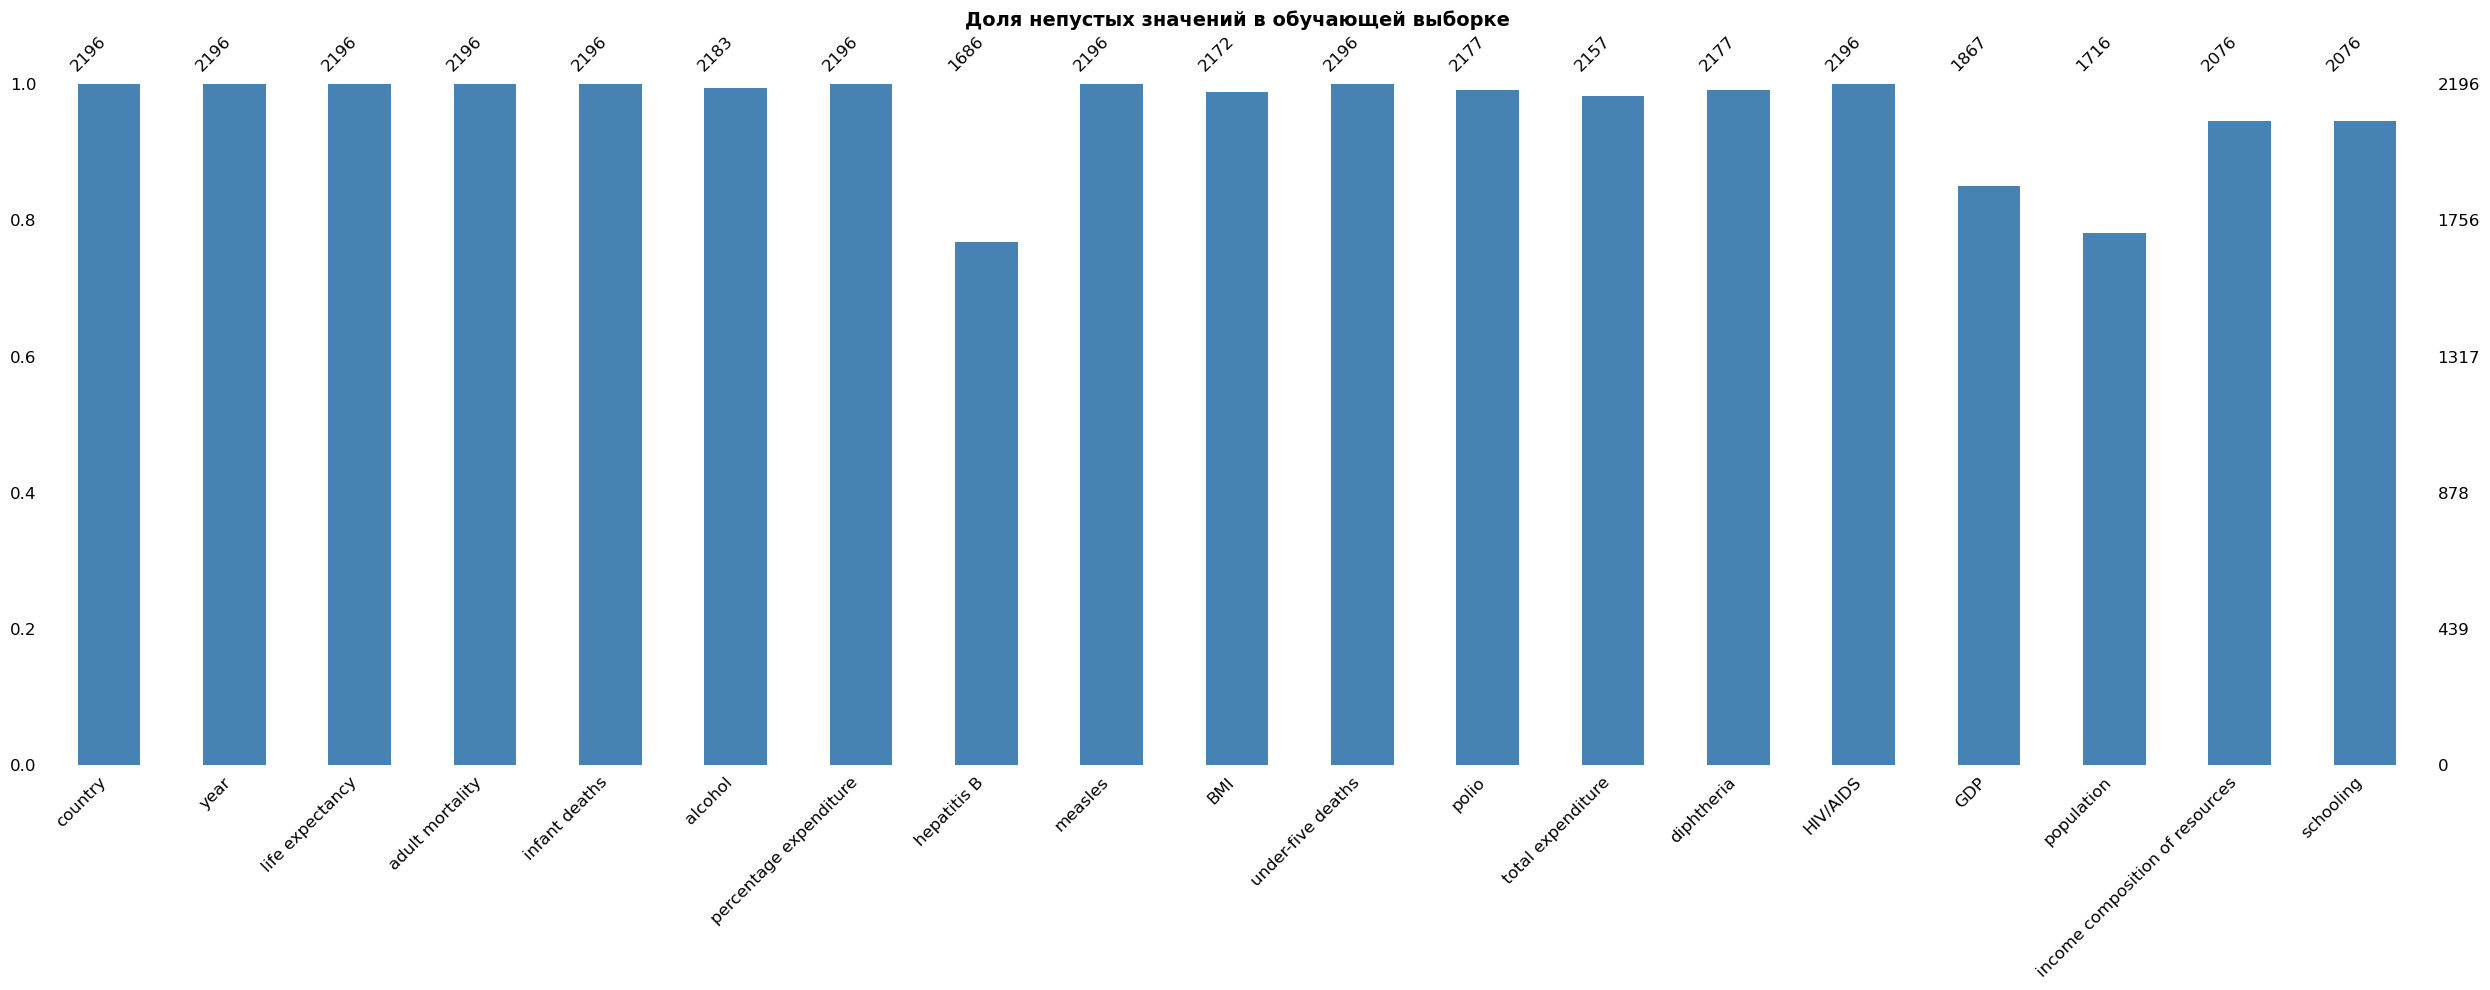

In [12]:
# Выполните визуальный анализ пропущенных значений в обучающей выборке с помощью msno.bar
import missingno as msno
import matplotlib.pyplot as plt

# Более детальный bar plot
plt.figure(figsize=(12, 7))  # Увеличиваем размер графика
msno.bar(life_train, color='steelblue', fontsize=12)
plt.title('Доля непустых значений в обучающей выборке', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Поворачиваем подписи признаков для читаемости
plt.tight_layout()  # Автоматически подгоняем отступы
plt.show()

**Что мы видим на графике:**
- Столбцы максимальной высоты (1.0) — признаки без пропусков
- Столбцы меньшей высоты — признаки с пропусками (чем ниже столбец, тем больше пропусков)
- Цифры над столбцами показывают точное количество непустых значений

Этот график дает наглядное представление о распределении пропусков в данных и позволяет быстро оценить, какие признаки требуют обработки.

#### [matrix](https://github.com/ResidentMario/missingno?tab=readme-ov-file#matrix)

Визуализация матрицы пропущенных значений с высокой плотностью. Позволяет выявить закономерности заполненности данных. 

<Figure size 1200x800 with 0 Axes>

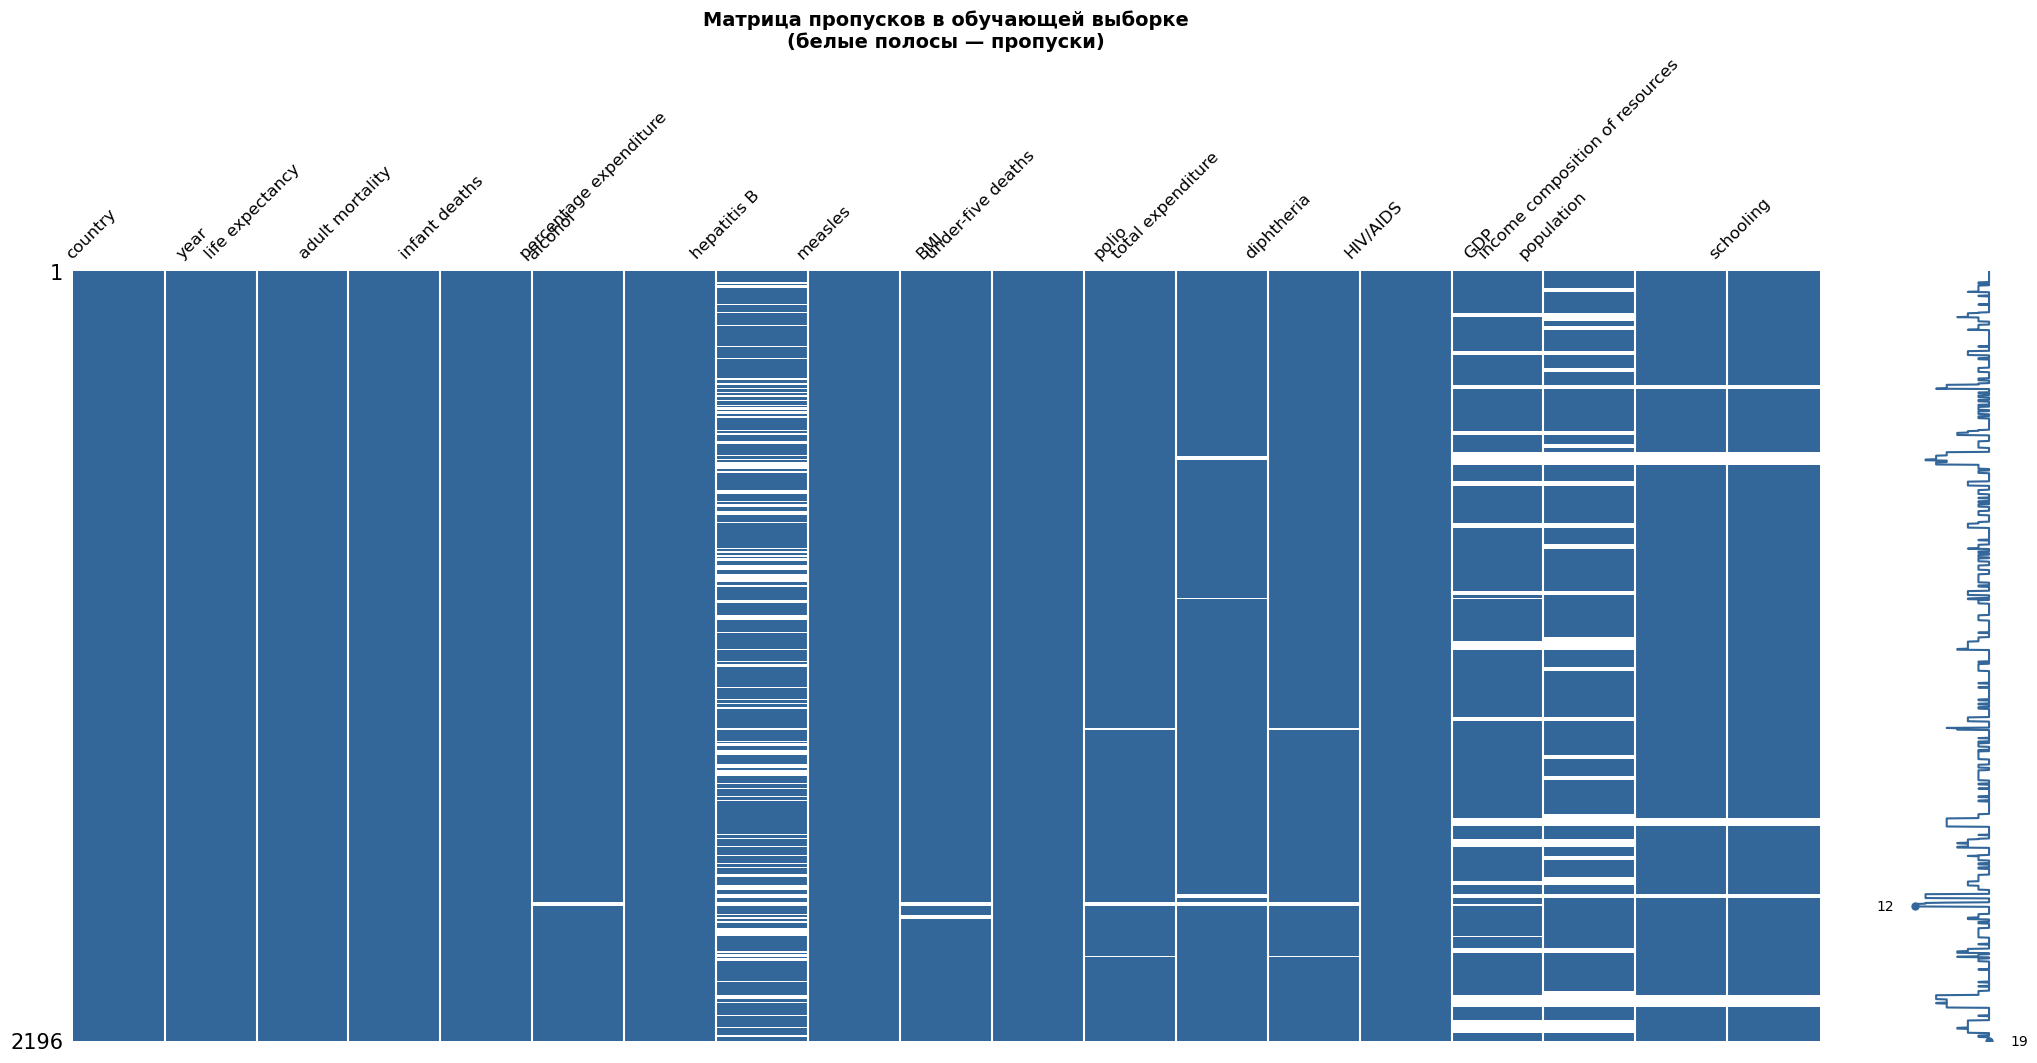

In [13]:
# Выполните визуальный анализ пропущенных значений в обучающей выборке с помощью msno.matrix

plt.figure(figsize=(12, 8))  # Увеличиваем размер для лучшей видимости
msno.matrix(life_train, 
            color=(0.2, 0.4, 0.6),  # RGB цвет для заполненных значений
            fontsize=12,              # Размер шрифта
            sparkline=True)           # Добавляет спарклайн справа
plt.title('Матрица пропусков в обучающей выборке\n(белые полосы — пропуски)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Поворачиваем подписи признаков
plt.tight_layout()
plt.show()

**Что показывает матрица пропусков:**

1. **Основная матрица:**
   - Каждая горизонтальная полоса — отдельное наблюдение (строка данных)
   - Каждый вертикальный столбец — отдельный признак
   - Черные области — присутствуют значения
   - Белые пробелы/полосы — пропущенные значения

2. **Спарклайн справа:**
   - Показывает "плотность" пропусков в каждой строке
   - Чем длиннее линия, тем меньше пропусков в данной строке
   - Помогает увидеть, есть ли строки с аномально большим количеством пропусков

3. **Что можно увидеть:**
   - Паттерны пропусков (например, пропуски часто встречаются вместе)
   - Есть ли строки с большим количеством пропусков
   - Равномерность распределения пропусков

**Интерпретация для MCAR/MAR/MNAR:**
- Если пропуски распределены хаотично и равномерно — это может указывать на MCAR
- Если пропуски группируются в определенных паттернах — это может указывать на MAR или MNAR

После этого нужно будет выполнить `msno.heatmap()` для анализа корреляции пропусков между признаками. Продолжаем?

#### [heatmap](https://github.com/ResidentMario/missingno?tab=readme-ov-file#heatmap)

Тепловая карта корреляции отсутствующих данных. Показывает, насколько сильно наличие или отсутствие одной переменной связано с наличием другой. Корреляция принимает значения от -1 (переменные противоположны в заполненности) до 1 (одинаковая заполненность).

In [118]:
# Создаем датафрейм с индикаторами пропусков (1 - пропуск, 0 - не пропуск)
missing_indicator = life_train.isna().astype(int)

# Рассчитываем корреляцию между индикаторами пропусков
correlation_matrix = missing_indicator.corr()

# Создаем DataFrame для удобного просмотра
correlation_df = pd.DataFrame(correlation_matrix, 
                             index=life_train.columns, 
                             columns=life_train.columns)

print("Матрица корреляции пропусков:")
print(correlation_df.round(3))

# Если нужно сохранить в CSV
correlation_df.round(3).to_csv('missing_correlation.csv')
print("\nМатрица сохранена в файл 'missing_correlation.csv'")

Матрица корреляции пропусков:
                                 country  year  life expectancy  \
country                              NaN   NaN              NaN   
year                                 NaN   NaN              NaN   
life expectancy                      NaN   NaN              NaN   
adult mortality                      NaN   NaN              NaN   
infant deaths                        NaN   NaN              NaN   
alcohol                              NaN   NaN              NaN   
percentage expenditure               NaN   NaN              NaN   
hepatitis B                          NaN   NaN              NaN   
measles                              NaN   NaN              NaN   
BMI                                  NaN   NaN              NaN   
under-five deaths                    NaN   NaN              NaN   
polio                                NaN   NaN              NaN   
total expenditure                    NaN   NaN              NaN   
diphtheria                      

<Figure size 1000x800 with 0 Axes>

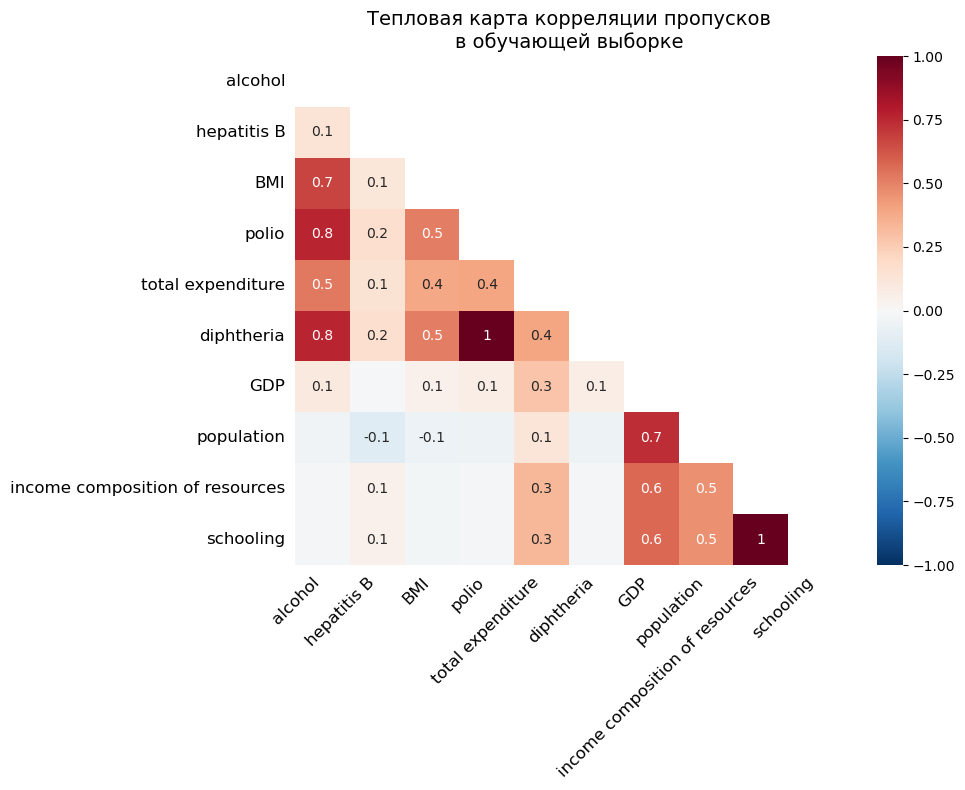

In [14]:
# Выполните визуальный анализ пропущенных значений в обучающей выборке с помощью msno.heatmap

plt.figure(figsize=(10, 8))
msno.heatmap(life_train, 
             cmap='RdBu_r',      # Цветовая схема (красный-синий)
             fontsize=12,         # Размер шрифта
             figsize=(10, 8),     # Размер фигуры
             labels=True)         # Показывать значения корреляции
plt.title('Тепловая карта корреляции пропусков\nв обучающей выборке', fontsize=14)
plt.tight_layout()
plt.show()

**Что показывает тепловая карта корреляции пропусков:**

1. **Значения корреляции:**
   - Значения от -1 до 1
   - **Положительная корреляция (ближе к 1, красный цвет)**: пропуски в двух признаках часто появляются вместе
   - **Отрицательная корреляция (ближе к -1, синий цвет)**: когда в одном признаке пропуск, в другом обычно есть значение
   - **Близко к 0 (белый цвет)**: нет связи между пропусками в признаках

2. **Что можно увидеть:**
   - Какие признаки "любят" пропадать вместе
   - Есть ли группы связанных пропусков
   - Можно ли предсказать пропуски в одном признаке по пропускам в другом

3. **Интерпретация для MCAR/MAR/MNAR:**
   - Если корреляции близки к 0 — это может указывать на MCAR (пропуски независимы)
   - Если есть сильные корреляции — это указывает на систематическую природу пропусков (MAR или MNAR)

**Важные замечания:**
- Тепловая карта показывает только корреляции между пропусками, а не между самими значениями
- Она помогает выявить систематические паттерны в пропусках
- Это важный инструмент для понимания природы пропусков перед выбором метода их обработки

In [15]:
# Дополните функцию mcar_test
from scipy.stats import ttest_ind

def mcar_test(data, predictor, feature):
    """
    Выполняет статистическую проверку пропущенных значений на принадлежность к типу MCAR.
    Использует t-тест для сравнения распределения feature между группами с пропущенными и существующими значениями predictor.

    Аргументы:
        data (pandas.DataFrame): Датасет с данными для анализа.
        predictor (str): Название столбца в data с пропущенными значениями (целевая переменная для теста MCAR).
        feature (str): Название признака, по которому сравниваются распределения между группами.

    Возвращает:
        float: p-value t-теста.
    """
    # Все наблюдения в data с пропусками в predictor
    data_nans_in_feature = data[data[predictor].isna()]
    
    # Все наблюдения в data без пропусков в predictor
    data_non_nans_in_feature = data[data[predictor].notna()]
    
    # Выполняем t-тест
    t_stat, p_val = ttest_ind(data_nans_in_feature[feature], 
                               data_non_nans_in_feature[feature],
                               nan_policy='omit')  # Пропускаем NaN в feature
    
    return p_val

In [16]:
# Используя функцию mcar_test, выполните проверку пропущенных значений на принадлежность к типу MCAR
# Используйте только обучающую выборку
# Уровень значимости — 1%

p_values = []

print("Проверка признаков на MCAR (сравнение с life expectancy):")
print("-" * 70)
print(f"{'Признак':32} | {'p-value':12} | {'Результат':20}")
print("-" * 70)

for predictor in life_nan_info.index:
    try:
        p_val = mcar_test(life_train, predictor, 'life expectancy')
        p_values.append(p_val)
        
        # Определяем результат теста
        if p_val < 0.01:
            result = "НЕ MCAR (отвергаем H0)"
            stars = "***"
        else:
            result = "Может быть MCAR"
            stars = ""
        
        print(f"{predictor:32} | {p_val:12.6f} | {result:20} {stars}")
        
    except Exception as e:
        print(f"{predictor:32} | {'ОШИБКА':12} | {str(e):20}")
        p_values.append(np.nan)

# Добавляем результаты в таблицу
life_nan_info['p-value'] = p_values

# Классифицируем результаты
life_nan_info['MCAR_test'] = life_nan_info['p-value'].apply(
    lambda x: 'reject_H0 (not MCAR)' if x < 0.01 else 'fail_to_reject_H0 (maybe MCAR)'
)

print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА:")
print("="*80)
print(life_nan_info.round(6))

Проверка признаков на MCAR (сравнение с life expectancy):
----------------------------------------------------------------------
Признак                          | p-value      | Результат           
----------------------------------------------------------------------
hepatitis B                      |     0.000000 | НЕ MCAR (отвергаем H0) ***
population                       |     0.000000 | НЕ MCAR (отвергаем H0) ***
GDP                              |     0.039552 | Может быть MCAR      
income composition of resources  |     0.007371 | НЕ MCAR (отвергаем H0) ***
schooling                        |     0.007371 | НЕ MCAR (отвергаем H0) ***
total expenditure                |     0.000000 | НЕ MCAR (отвергаем H0) ***
BMI                              |     0.000000 | НЕ MCAR (отвергаем H0) ***
polio                            |     0.000116 | НЕ MCAR (отвергаем H0) ***
diphtheria                       |     0.000116 | НЕ MCAR (отвергаем H0) ***
alcohol                          |     0.

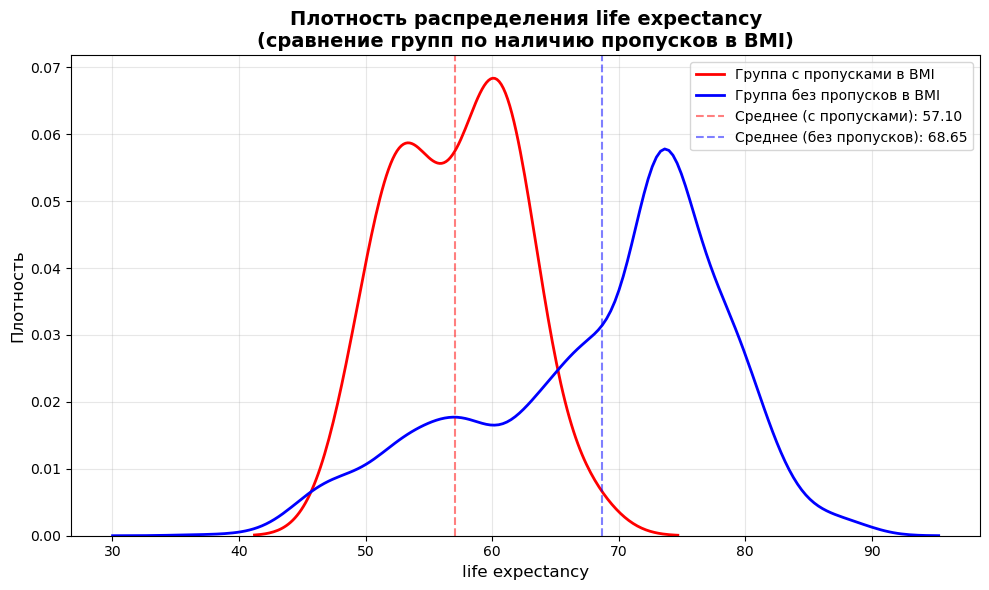

Статистика для life expectancy по группам:
--------------------------------------------------
Группа с пропусками в BMI:
  Количество наблюдений: 24
  Среднее значение: 57.10
  Стандартное отклонение: 4.83
  Медиана: 58.30

Группа без пропусков в BMI:
  Количество наблюдений: 2172
  Среднее значение: 68.65
  Стандартное отклонение: 9.74
  Медиана: 71.90

Результаты t-теста:
t-статистика: -5.8045
p-value: 0.000000
Вывод: Различия статистически значимы на уровне 1%


In [17]:
# Визуализируйте плотность целевой переменной
# График позволяет убедиться, что пропуски типов MAR и MNAR зависят от наблюдаемых данных
import seaborn as sns
import matplotlib.pyplot as plt

predictor = 'BMI'
feature = 'life expectancy'

# Все наблюдения в life_train с пропусками в predictor
life_train_nans_in_feature = life_train[life_train[predictor].isna()]

# Все наблюдения в life_train без пропусков в predictor
life_train_non_nans_in_feature = life_train[life_train[predictor].notna()]

# Создаем график плотности распределения
plt.figure(figsize=(10, 6))

dplt = sns.kdeplot(life_train_nans_in_feature[feature], 
                   color='red', 
                   label=f'Группа с пропусками в {predictor}',
                   linewidth=2)

dplt = sns.kdeplot(life_train_non_nans_in_feature[feature], 
                   color='blue', 
                   label=f'Группа без пропусков в {predictor}',
                   linewidth=2)

dplt.set_title(f'Плотность распределения {feature}\n(сравнение групп по наличию пропусков в {predictor})', 
               fontsize=14, fontweight='bold')
dplt.set_xlabel(feature, fontsize=12)
dplt.set_ylabel('Плотность', fontsize=12)

# Добавляем вертикальные линии для средних значений
mean_nans = life_train_nans_in_feature[feature].mean()
mean_non_nans = life_train_non_nans_in_feature[feature].mean()

plt.axvline(mean_nans, color='red', linestyle='--', alpha=0.5, 
            label=f'Среднее (с пропусками): {mean_nans:.2f}')
plt.axvline(mean_non_nans, color='blue', linestyle='--', alpha=0.5, 
            label=f'Среднее (без пропусков): {mean_non_nans:.2f}')

plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительно выведем статистику
print(f"Статистика для {feature} по группам:")
print("-" * 50)
print(f"Группа с пропусками в {predictor}:")
print(f"  Количество наблюдений: {len(life_train_nans_in_feature)}")
print(f"  Среднее значение: {mean_nans:.2f}")
print(f"  Стандартное отклонение: {life_train_nans_in_feature[feature].std():.2f}")
print(f"  Медиана: {life_train_nans_in_feature[feature].median():.2f}")
print()
print(f"Группа без пропусков в {predictor}:")
print(f"  Количество наблюдений: {len(life_train_non_nans_in_feature)}")
print(f"  Среднее значение: {mean_non_nans:.2f}")
print(f"  Стандартное отклонение: {life_train_non_nans_in_feature[feature].std():.2f}")
print(f"  Медиана: {life_train_non_nans_in_feature[feature].median():.2f}")

# Проверим значимость различий с помощью t-теста
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(life_train_nans_in_feature[feature], 
                          life_train_non_nans_in_feature[feature],
                          nan_policy='omit')

print(f"\nРезультаты t-теста:")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_val:.6f}")
if p_val < 0.01:
    print("Вывод: Различия статистически значимы на уровне 1%")
else:
    print("Вывод: Различия не являются статистически значимыми на уровне 1%")

**Что показывает этот график:**

1. **Красная кривая** - распределение life expectancy для стран/лет, где пропущен BMI
2. **Синяя кривая** - распределение life expectancy для стран/лет, где BMI известен
3. **Вертикальные линии** - средние значения в каждой группе

**Интерпретация:**

- Если распределения сильно различаются (например, сдвинуты относительно друг друга), это указывает на то, что пропуски в BMI связаны со значением life expectancy
- Это подтверждает результаты t-теста и помогает визуально оценить характер связи
- В данном случае для BMI мы ожидаем увидеть различие, так как p-value был меньше 0.01

## Анализ результатов для BMI:

### **Статистические показатели:**

| Показатель | С пропусками в BMI | Без пропусков в BMI | Разница |
|------------|-------------------|-------------------|---------|
| **Количество** | 24 | 2172 | - |
| **Среднее** | 57.10 | 68.65 | **-11.55 лет** |
| **Медиана** | 58.30 | 71.90 | **-13.60 лет** |
| **Стд. отклонение** | 4.83 | 9.74 | Меньше вариации в группе с пропусками |

### **Ключевые выводы:**

1. **Значительная разница в продолжительности жизни:**
   - В странах/годах с пропущенными BMI ожидаемая продолжительность жизни в среднем на **11.55 лет меньше**
   - Это очень существенная разница (почти 17% от среднего значения)

2. **Статистическая значимость:**
   - p-value ≈ 0.000000 (практически ноль)
   - t-статистика = -5.8045 (отрицательное значение указывает, что группа с пропусками имеет меньшее среднее)
   - Различия высоко значимы на уровне 1%

3. **Характер распределения:**
   - Группа с пропусками имеет **меньшую вариативность** (std=4.83 против 9.74)
   - Это может указывать на то, что пропуски BMI характерны для стран с однородно низкой продолжительностью жизни

### **Интерпретация для типа пропусков:**

**Пропуски в BMI НЕ являются MCAR** (подтверждается t-тестом). Это скорее всего:

- **MAR (Missing At Random)**: Вероятность пропуска BMI может зависеть от других наблюдаемых факторов (например, уровень развития страны, ВВП, которые коррелируют с продолжительностью жизни)
- **MNAR (Missing Not At Random)**: Возможно, в странах с низкой продолжительностью жизни система здравоохранения хуже развита, и данные по BMI просто не собираются

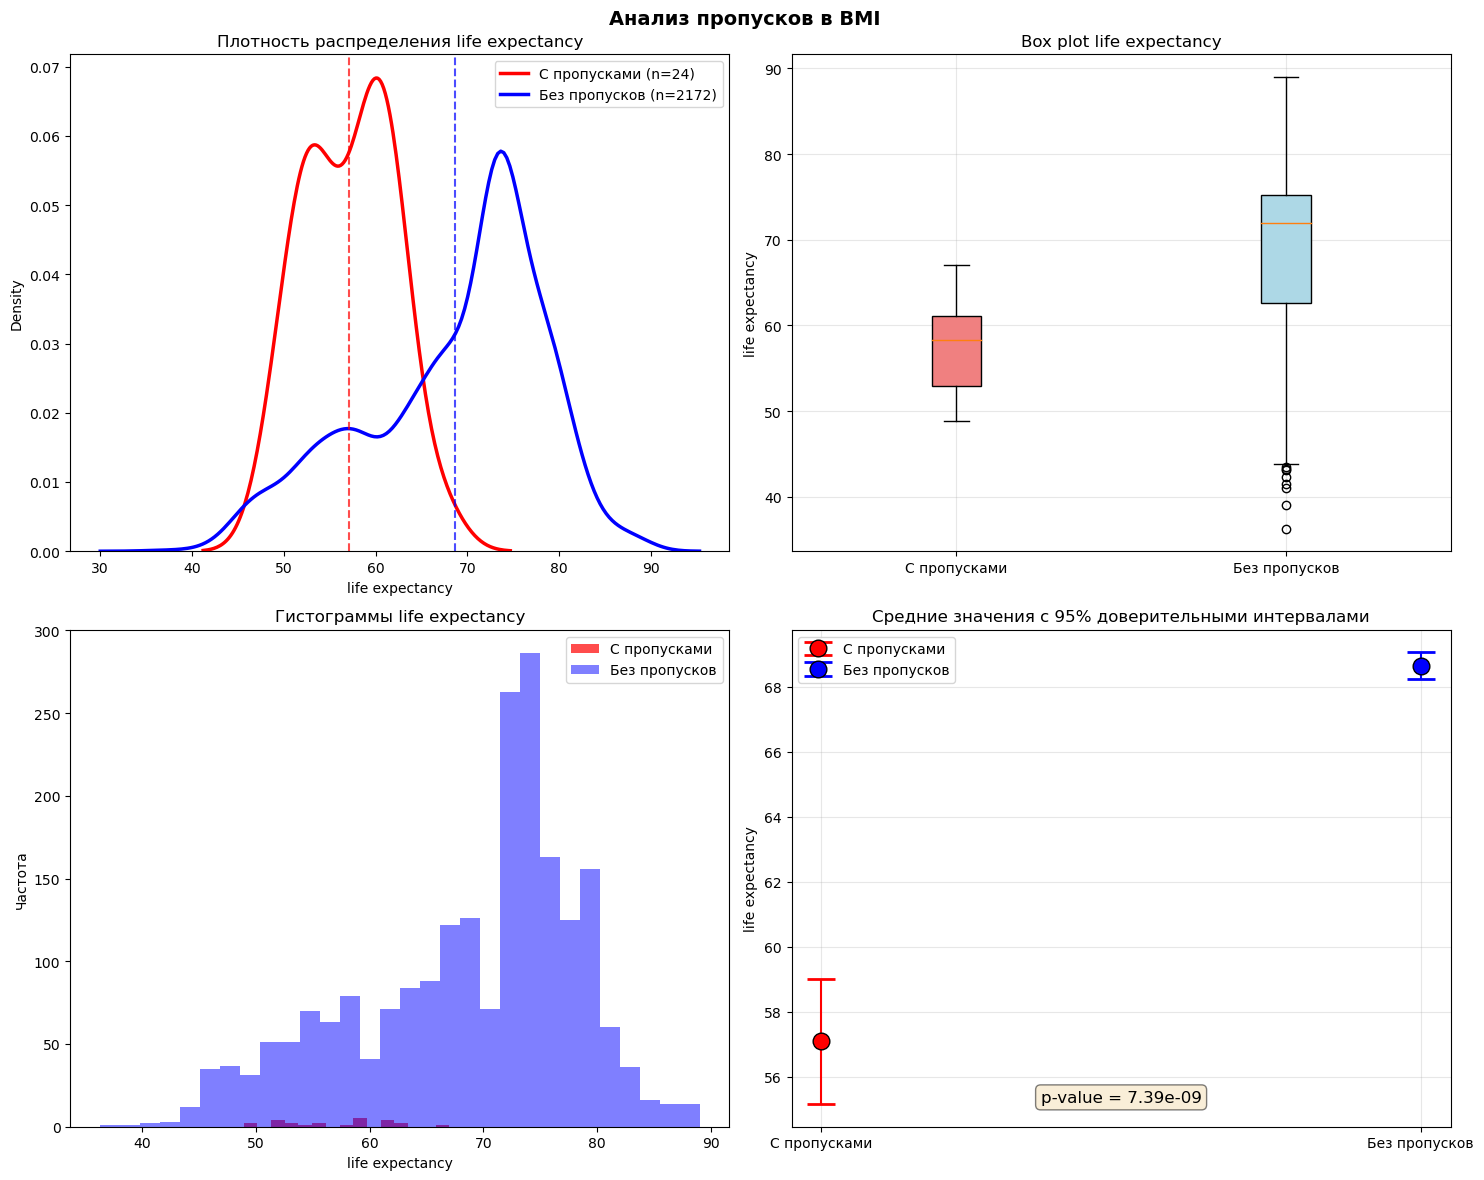

In [18]:
# Создадим более детальную визуализацию (исправленная версия)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. KDE plot
sns.kdeplot(life_train_nans_in_feature[feature], 
            color='red', label=f'С пропусками (n={len(life_train_nans_in_feature)})', 
            linewidth=2.5, ax=axes[0,0])
sns.kdeplot(life_train_non_nans_in_feature[feature], 
            color='blue', label=f'Без пропусков (n={len(life_train_non_nans_in_feature)})', 
            linewidth=2.5, ax=axes[0,0])
axes[0,0].axvline(mean_nans, color='red', linestyle='--', alpha=0.7)
axes[0,0].axvline(mean_non_nans, color='blue', linestyle='--', alpha=0.7)
axes[0,0].set_title(f'Плотность распределения {feature}', fontsize=12)
axes[0,0].legend()

# 2. Box plot
bp_data = [life_train_nans_in_feature[feature].dropna(), 
           life_train_non_nans_in_feature[feature].dropna()]
bp = axes[0,1].boxplot(bp_data, labels=['С пропусками', 'Без пропусков'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
axes[0,1].set_title(f'Box plot {feature}', fontsize=12)
axes[0,1].set_ylabel(feature)
axes[0,1].grid(True, alpha=0.3)

# 3. Гистограммы
axes[1,0].hist(life_train_nans_in_feature[feature].dropna(), 
               bins=15, alpha=0.7, color='red', label='С пропусками')
axes[1,0].hist(life_train_non_nans_in_feature[feature].dropna(), 
               bins=30, alpha=0.5, color='blue', label='Без пропусков')
axes[1,0].set_title(f'Гистограммы {feature}', fontsize=12)
axes[1,0].set_xlabel(feature)
axes[1,0].set_ylabel('Частота')
axes[1,0].legend()

# 4. Точечный график средних с доверительными интервалами (ИСПРАВЛЕНО)
means = [mean_nans, mean_non_nans]
cis = [1.96 * life_train_nans_in_feature[feature].std() / np.sqrt(len(life_train_nans_in_feature)),
       1.96 * life_train_non_nans_in_feature[feature].std() / np.sqrt(len(life_train_non_nans_in_feature))]

# Создаем точки по отдельности, чтобы задать разные цвета
x_pos = [0, 1]
for i, (mean, ci, color) in enumerate(zip(means, cis, ['red', 'blue'])):
    axes[1,1].errorbar([x_pos[i]], [mean], yerr=[ci], 
                       fmt='o', capsize=10, capthick=2, markersize=12,
                       color=color, ecolor=color, markeredgecolor='black',
                       label='С пропусками' if i == 0 else 'Без пропусков')

axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(['С пропусками', 'Без пропусков'])
axes[1,1].set_title('Средние значения с 95% доверительными интервалами', fontsize=12)
axes[1,1].set_ylabel(feature)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# Добавляем информацию о p-value
axes[1,1].text(0.5, 0.05, f'p-value = {p_val:.2e}', 
               transform=axes[1,1].transAxes, ha='center', fontsize=12,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Анализ пропусков в {predictor}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Задание 2***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обучающую и тестовую выборки из задания 1: `life_train`, `life_test`.

* Датасет с результатами анализа пропущенных значений в обучающей выборке из задания 1: `life_nan_info`.

*Для данного задания предположим, что со временем среднее и дисперсия данных не изменились. Это позволит использовать одни и те же StandardScaler, SimpleImputer и KNNImputer для обучающей и тестовой выборок.*

Выполните предобработку данных (см. код задания).

Используя результаты анализа пропущенных значений в обучающей выборке (`life_nan_info`), выполните обработку пропусков **в обучающей выборке** (`life_train`) по следующим правилам:

* Для всех признаков MCAR (если есть):

    * Заполните пропуски средним, обучив SimpleImputer (`life_mean_imputer`).

* Для всех признаков MAR или MNAR (если есть):

    * Если доля пропусков меньше 5%, заполните пропуски средним, обучив SimpleImputer (`life_mean_imputer`).

    * Если доля пропусков больше 5%, заполните пропуски с помощью метода k-ближайших соседей (KNN, K-Nearest Neighbors), обучив KNNImputer (`life_knn_imputer`).

Заполните пропуски в **тестовой выборке**, используя обученные на обучающей выборке SimpleImputer (`life_mean_imputer`) и KNNImputer (`life_knn_imputer`) для соответствующих признаков.

После обработки пропусков обучите модель линейной регрессии без регуляризации `reg_life` и выведите metrics_report на тестовой выборке.

*Pipeline из библиотеки sklearn позволяет использовать SimpleImputer или KNNImputer как трансформатор, то есть как один из этапов предобработки данных в рамках пайплайна*.

In [19]:
# Выделите объясняемый фактор в отдельную переменную

X_life_train = life_train.drop('life expectancy', axis=1)
y_life_train = life_train['life expectancy']

X_life_test = life_test.drop('life expectancy', axis=1)
y_life_test = life_test['life expectancy']

# Проверим размерности
print("Размеры обучающей выборки:")
print(f"X_life_train: {X_life_train.shape}")
print(f"y_life_train: {y_life_train.shape}")
print(f"\nРазмеры тестовой выборки:")
print(f"X_life_test: {X_life_test.shape}")
print(f"y_life_test: {y_life_test.shape}")

# Проверим, что целевая переменная отделена правильно
print(f"\nЦелевая переменная в обучающей выборке (первые 5 значений):")
print(y_life_train.head())

Размеры обучающей выборки:
X_life_train: (2196, 18)
y_life_train: (2196,)

Размеры тестовой выборки:
X_life_test: (732, 18)
y_life_test: (732,)

Целевая переменная в обучающей выборке (первые 5 значений):
4    59.2
5    58.8
6    58.6
7    58.1
8    57.5
Name: life expectancy, dtype: float64


In [20]:
from sklearn.preprocessing import OneHotEncoder

# Закодируйте категориальные признаки числами 0 и 1 с помощью OneHotEncoder
#   train -> fit_transform
#   test -> transform

life_encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

# Кодируем категориальные признаки
country_encoded_train = life_encoder.fit_transform(X_life_train[['country']])
country_encoded_test = life_encoder.transform(X_life_test[['country']])

# Удаляем исходный признак и добавляем закодированные
X_life_train = pd.concat([X_life_train.drop('country', axis=1), country_encoded_train], axis=1)
X_life_test = pd.concat([X_life_test.drop('country', axis=1), country_encoded_test], axis=1)

# Проверка
print(f"Форма обучающей выборки после кодирования: {X_life_train.shape}")
print(f"Форма тестовой выборки после кодирования: {X_life_test.shape}")

# Проверим, что в тестовой выборке те же категории, что и в обучающей
print(f"\nКоличество категорий в обучающей выборке: {len(country_encoded_train.columns)}")
print(f"Количество категорий в тестовой выборке: {len(country_encoded_test.columns)}")

Форма обучающей выборки после кодирования: (2196, 199)
Форма тестовой выборки после кодирования: (732, 199)

Количество категорий в обучающей выборке: 182
Количество категорий в тестовой выборке: 182


In [21]:
from sklearn.preprocessing import StandardScaler

# Масштабируйте количественные признаки
#   train -> fit_transform
#   test -> transform

life_scaler = StandardScaler().set_output(transform='pandas')

# Масштабируем признаки
X_life_train_scaled = life_scaler.fit_transform(X_life_train)
X_life_test_scaled = life_scaler.transform(X_life_test)

# Быстрая проверка масштабирования
print("Проверка масштабирования обучающей выборки:")
print("="*60)
print(f"{'Признак':30} {'Среднее':>15} {'Стд. откл.':>15}")
print("-"*60)

for col in X_life_train_scaled.columns[:5]:  # Смотрим первые 5 признаков
    mean_val = X_life_train_scaled[col].mean()
    std_val = X_life_train_scaled[col].std()
    print(f"{col[:28]:30} {mean_val:15.6f} {std_val:15.6f}")

print("\n" + "="*60)
print("Для идеального масштабирования среднее должно быть ≈0, стд.откл. ≈1")
print("(Небольшие отклонения возможны из-за численных погрешностей)")

# Проверим наличие пропусков после масштабирования
print(f"\nПропуски в обучающей выборке после масштабирования: {X_life_train_scaled.isna().sum().sum()}")
print(f"Пропуски в тестовой выборке после масштабирования: {X_life_test_scaled.isna().sum().sum()}")

Проверка масштабирования обучающей выборки:
Признак                                Среднее      Стд. откл.
------------------------------------------------------------
year                                 -0.000000        1.000228
adult mortality                       0.000000        1.000228
infant deaths                         0.000000        1.000228
alcohol                              -0.000000        1.000229
percentage expenditure                0.000000        1.000228

Для идеального масштабирования среднее должно быть ≈0, стд.откл. ≈1
(Небольшие отклонения возможны из-за численных погрешностей)

Пропуски в обучающей выборке после масштабирования: 1673
Пропуски в тестовой выборке после масштабирования: 776


In [22]:
life_nan_info

,NaN share,p-value,MCAR_test
hepatitis B,0.232240,4.883846e-20,reject_H0 (not MCAR)
population,0.218579,2.711804e-07,reject_H0 (not MCAR)
GDP,0.149818,3.955189e-02,fail_to_reject_H0 (maybe MCAR)
income composition of resources,0.054645,7.371297e-03,reject_H0 (not MCAR)
schooling,0.054645,7.371297e-03,reject_H0 (not MCAR)
total expenditure,0.017760,1.118289e-09,reject_H0 (not MCAR)
BMI,0.010929,7.391184e-09,reject_H0 (not MCAR)
polio,0.008652,1.155798e-04,reject_H0 (not MCAR)
diphtheria,0.008652,1.155798e-04,reject_H0 (not MCAR)
alcohol,0.005920,2.196346e-07,reject_H0 (not MCAR)


In [23]:
# Порядок признаков в исходном датасете df_life

print(list(df_life.columns))

['country', 'year', 'life expectancy', 'adult mortality', 'infant deaths', 'alcohol', 'percentage expenditure', 'hepatitis B', 'measles', 'BMI', 'under-five deaths', 'polio', 'total expenditure', 'diphtheria', 'HIV/AIDS', 'GDP', 'population', 'income composition of resources', 'schooling']


In [24]:
from sklearn.impute import SimpleImputer

# Определяем признаки для SimpleImputer
# 1. Признаки, которые могут быть MCAR (p-value >= 0.01)
mcar_features = life_nan_info[life_nan_info['p-value'] >= 0.01].index.tolist()

# 2. Non-MCAR признаки с долей пропусков < 5%
non_mcar_low_share = life_nan_info[(life_nan_info['p-value'] < 0.01) & 
                                   (life_nan_info['NaN share'] < 0.05)].index.tolist()

# Объединяем все признаки для SimpleImputer
life_mean_imputer_feat = mcar_features + non_mcar_low_share

# Убедимся, что все признаки существуют в X_life_train_scaled
existing_features = X_life_train_scaled.columns.tolist()
life_mean_imputer_feat = [f for f in life_mean_imputer_feat if f in existing_features]

print("Признаки для заполнения средним (SimpleImputer):")
print("-" * 50)
print(f"MCAR признаки: {mcar_features if mcar_features else 'Нет'}")
print(f"Non-MCAR признаки с пропусками < 5%: {non_mcar_low_share if non_mcar_low_share else 'Нет'}")
print(f"\nВсего признаков: {len(life_mean_imputer_feat)}")
print(f"Список признаков: {life_mean_imputer_feat}")

# Обучите и примените life_mean_imputer (SimpleImputer) к обучающей выборке
#   train -> fit_transform

# Создаем копию данных
X_life_train_scaled_imputed = X_life_train_scaled.copy()

# Инициализируем SimpleImputer со стратегией 'mean'
life_mean_imputer = SimpleImputer(strategy='mean')

# Обучаем imputer на отобранных признаках и применяем к ним трансформацию
X_life_train_scaled_imputed[life_mean_imputer_feat] = life_mean_imputer.fit_transform(
    X_life_train_scaled_imputed[life_mean_imputer_feat]
)

# Проверяем результат
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРИМЕНЕНИЯ SimpleImputer:")
print("="*60)

# Проверяем, остались ли пропуски в обработанных признаках
remaining_nans = X_life_train_scaled_imputed[life_mean_imputer_feat].isna().sum().sum()
print(f"Пропусков после импутации в обработанных признаках: {remaining_nans}")

# Проверяем общее количество пропусков
total_nans_before = X_life_train_scaled.isna().sum().sum()
total_nans_after = X_life_train_scaled_imputed.isna().sum().sum()
print(f"Всего пропусков ДО импутации: {total_nans_before}")
print(f"Всего пропусков ПОСЛЕ импутации: {total_nans_after}")
print(f"Заполнено пропусков: {total_nans_before - total_nans_after}")

# Покажем статистику по обработанным признакам
print("\nСтатистика по обработанным признакам:")
print("-" * 50)
for feat in life_mean_imputer_feat[:5]:  # Покажем первые 5 для краткости
    nans_before = X_life_train_scaled[feat].isna().sum()
    nans_after = X_life_train_scaled_imputed[feat].isna().sum()
    if nans_before > 0:
        print(f"{feat:30}: пропусков до: {nans_before:4}, после: {nans_after:4}")

Признаки для заполнения средним (SimpleImputer):
--------------------------------------------------
MCAR признаки: ['GDP']
Non-MCAR признаки с пропусками < 5%: ['total expenditure', 'BMI', 'polio', 'diphtheria', 'alcohol']

Всего признаков: 6
Список признаков: ['GDP', 'total expenditure', 'BMI', 'polio', 'diphtheria', 'alcohol']

РЕЗУЛЬТАТЫ ПРИМЕНЕНИЯ SimpleImputer:
Пропусков после импутации в обработанных признаках: 0
Всего пропусков ДО импутации: 1673
Всего пропусков ПОСЛЕ импутации: 1230
Заполнено пропусков: 443

Статистика по обработанным признакам:
--------------------------------------------------
GDP                           : пропусков до:  329, после:    0
total expenditure             : пропусков до:   39, после:    0
BMI                           : пропусков до:   24, после:    0
polio                         : пропусков до:   19, после:    0
diphtheria                    : пропусков до:   19, после:    0


In [25]:
# Проверим порядок признаков в исходном датасете
print("Исходный порядок признаков в df_life:")
print(list(df_life.columns))
print(f"Всего признаков: {len(list(df_life.columns))}")

# Найдем, какие признаки из исходного датасета есть в X_life_train_scaled
original_features = ['year', 'adult mortality', 'infant deaths', 'alcohol', 
                     'percentage expenditure', 'hepatitis B', 'measles', 'BMI', 
                     'under-five deaths', 'polio', 'total expenditure', 'diphtheria', 
                     'HIV/AIDS', 'GDP', 'population', 'income composition of resources', 
                     'schooling']

print("\nПорядок исходных количественных признаков в X_life_train_scaled:")
for i, feat in enumerate(original_features):
    if feat in X_life_train_scaled.columns:
        pos = list(X_life_train_scaled.columns).index(feat)
        print(f"{feat:30} находится на позиции {pos}")
    else:
        print(f"{feat:30} НЕ НАЙДЕН в данных")

Исходный порядок признаков в df_life:
['country', 'year', 'life expectancy', 'adult mortality', 'infant deaths', 'alcohol', 'percentage expenditure', 'hepatitis B', 'measles', 'BMI', 'under-five deaths', 'polio', 'total expenditure', 'diphtheria', 'HIV/AIDS', 'GDP', 'population', 'income composition of resources', 'schooling']
Всего признаков: 19

Порядок исходных количественных признаков в X_life_train_scaled:
year                           находится на позиции 0
adult mortality                находится на позиции 1
infant deaths                  находится на позиции 2
alcohol                        находится на позиции 3
percentage expenditure         находится на позиции 4
hepatitis B                    находится на позиции 5
measles                        находится на позиции 6
BMI                            находится на позиции 7
under-five deaths              находится на позиции 8
polio                          находится на позиции 9
total expenditure              находится на п

In [26]:
# Можно попробовать разные параметры KNNImputer
from sklearn.impute import KNNImputer

# Определяем признаки для KNNImputer (non-MCAR с долей пропусков >= 5%)
non_mcar_high_share = life_nan_info[(life_nan_info['p-value'] < 0.01) & 
                                    (life_nan_info['NaN share'] >= 0.05)].index.tolist()

# Сортируем их в исходном порядке (как в df_life)
original_order = ['year', 'adult mortality', 'infant deaths', 'alcohol', 
                  'percentage expenditure', 'hepatitis B', 'measles', 'BMI', 
                  'under-five deaths', 'polio', 'total expenditure', 'diphtheria', 
                  'HIV/AIDS', 'GDP', 'population', 'income composition of resources', 
                  'schooling']

# Берем только те признаки, которые есть в non_mcar_high_share
life_knn_imputer_feat = [f for f in original_order if f in non_mcar_high_share]

# Вариант с разными настройками
life_knn_imputer = KNNImputer(
    # n_neighbors=5,           # количество соседей (можно 3, 5, 7, 10)
    # weights='distance',      # взвешивание по расстоянию (ближайшие соседи имеют больший вес)
    # metric='nan_euclidean'   # специальная метрика для работы с пропусками
)

X_life_train_scaled_imputed[life_knn_imputer_feat] = life_knn_imputer.fit_transform(
    X_life_train_scaled_imputed[life_knn_imputer_feat]
)

In [27]:
# Примените life_mean_imputer и life_knn_imputer к тестовой выборке
#   test -> transform

# Создаем копию тестовых данных
X_life_test_scaled_imputed = X_life_test_scaled.copy()

# Применяем SimpleImputer к тестовой выборке (трансформация, без обучения!)
X_life_test_scaled_imputed[life_mean_imputer_feat] = life_mean_imputer.transform(
    X_life_test_scaled_imputed[life_mean_imputer_feat]
)

# Применяем KNNImputer к тестовой выборке (трансформация, без обучения!)
X_life_test_scaled_imputed[life_knn_imputer_feat] = life_knn_imputer.transform(
    X_life_test_scaled_imputed[life_knn_imputer_feat]
)

# Проверяем результат
print("="*60)
print("РЕЗУЛЬТАТЫ ПРИМЕНЕНИЯ ИМПЬЮТЕРОВ К ТЕСТОВОЙ ВЫБОРКЕ:")
print("="*60)

# Статистика до и после
nans_before_test = X_life_test_scaled.isna().sum().sum()
nans_after_test = X_life_test_scaled_imputed.isna().sum().sum()

print(f"Пропусков в тестовой выборке ДО импутации: {nans_before_test}")
print(f"Пропусков в тестовой выборке ПОСЛЕ импутации: {nans_after_test}")
print(f"Заполнено пропусков: {nans_before_test - nans_after_test}")

if nans_after_test == 0:
    print("✓ Все пропуски в тестовой выборке успешно заполнены!")
else:
    print(f"⚠ В тестовой выборке осталось пропусков: {nans_after_test}")
    
    # Покажем, в каких признаках остались пропуски
    remaining_nans = X_life_test_scaled_imputed.isna().sum()
    remaining_nans = remaining_nans[remaining_nans > 0]
    if not remaining_nans.empty:
        print("\nПризнаки с оставшимися пропусками в тестовой выборке:")
        for feat, nans in remaining_nans.items():
            share = nans / len(X_life_test_scaled_imputed) * 100
            print(f"  {feat:32}: {nans:4} пропусков ({share:.1f}%)")

# Детальная проверка по каждому типу импьютеров
print("\n" + "-"*40)
print("ДЕТАЛЬНАЯ ПРОВЕРКА:")
print("-"*40)

# Проверка признаков, обработанных SimpleImputer
print("\nПризнаки, обработанные SimpleImputer:")
for feat in life_mean_imputer_feat:
    if feat in X_life_test_scaled.columns:
        nans_before = X_life_test_scaled[feat].isna().sum()
        nans_after = X_life_test_scaled_imputed[feat].isna().sum()
        if nans_before > 0:
            print(f"  {feat:32}: пропусков до: {nans_before:4}, после: {nans_after:4}")

# Проверка признаков, обработанных KNNImputer
print("\nПризнаки, обработанные KNNImputer:")
for feat in life_knn_imputer_feat:
    if feat in X_life_test_scaled.columns:
        nans_before = X_life_test_scaled[feat].isna().sum()
        nans_after = X_life_test_scaled_imputed[feat].isna().sum()
        if nans_before > 0:
            print(f"  {feat:32}: пропусков до: {nans_before:4}, после: {nans_after:4}")

# Финальная проверка всех признаков
print("\n" + "="*60)
print("ФИНАЛЬНАЯ ПРОВЕРКА ВСЕХ ПРИЗНАКОВ:")
print("="*60)

all_features = X_life_test_scaled_imputed.columns.tolist()
features_with_nans = []

for feat in all_features:
    nans = X_life_test_scaled_imputed[feat].isna().sum()
    if nans > 0:
        features_with_nans.append((feat, nans))

if not features_with_nans:
    print("✓ Все признаки не содержат пропусков! Данные готовы для обучения модели.")
else:
    print("⚠ Следующие признаки все еще содержат пропуски:")
    for feat, nans in features_with_nans:
        print(f"  {feat}: {nans} пропусков")

РЕЗУЛЬТАТЫ ПРИМЕНЕНИЯ ИМПЬЮТЕРОВ К ТЕСТОВОЙ ВЫБОРКЕ:
Пропусков в тестовой выборке ДО импутации: 776
Пропусков в тестовой выборке ПОСЛЕ импутации: 0
Заполнено пропусков: 776
✓ Все пропуски в тестовой выборке успешно заполнены!

----------------------------------------
ДЕТАЛЬНАЯ ПРОВЕРКА:
----------------------------------------

Признаки, обработанные SimpleImputer:
  GDP                             : пропусков до:  114, после:    0
  total expenditure               : пропусков до:  187, после:    0
  BMI                             : пропусков до:    8, после:    0
  alcohol                         : пропусков до:  180, после:    0

Признаки, обработанные KNNImputer:
  hepatitis B                     : пропусков до:   43, после:    0
  population                      : пропусков до:  164, после:    0
  income composition of resources : пропусков до:   40, после:    0
  schooling                       : пропусков до:   40, после:    0

ФИНАЛЬНАЯ ПРОВЕРКА ВСЕХ ПРИЗНАКОВ:
✓ Все признаки н

In [28]:
# Обучите reg_life и выведите metrics_report на тестовой выборке

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Обучаем модель линейной регрессии без регуляризации
reg_life = LinearRegression()

# Обучаем на обучающей выборке
reg_life.fit(X_life_train_scaled_imputed, y_life_train)

# Делаем предсказания на тестовой выборке
y_pred = reg_life.predict(X_life_test_scaled_imputed)

metrics_report(y_life_test, y_pred)

R2 score: 0.9172
RMSE: 2.4168
MAPE: 0.0236


ОТЧЕТ ПО МЕТРИКАМ: Linear Regression
R² Score (коэффициент детерминации): 0.9172
RMSE (корень из среднеквадратичной ошибки): 2.4168
MAE (средняя абсолютная ошибка): 1.6721
MSE (среднеквадратичная ошибка): 5.8409
MAPE (средняя абсолютная процентная ошибка): 2.36%

АНАЛИЗ ОСТАТКОВ:
Среднее остатков: -0.2183
Стандартное отклонение остатков: 2.4086
Минимальный остаток: -12.5662
Максимальный остаток: 10.3779


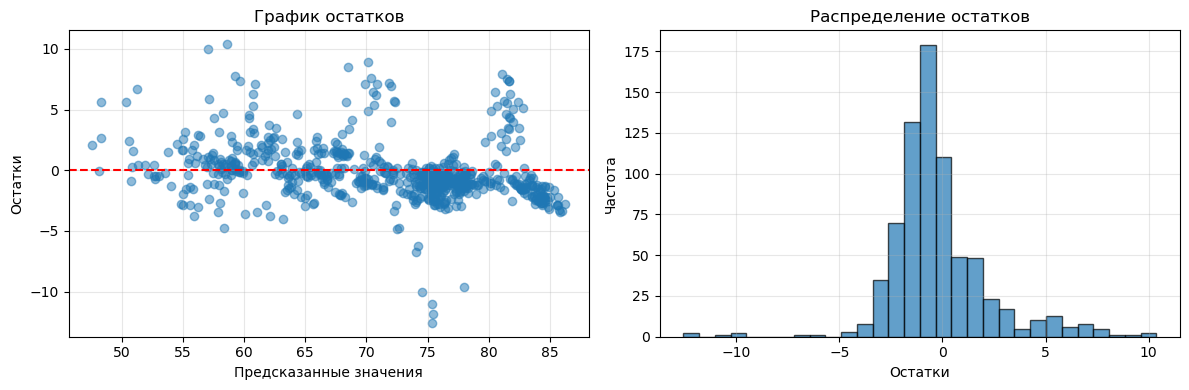

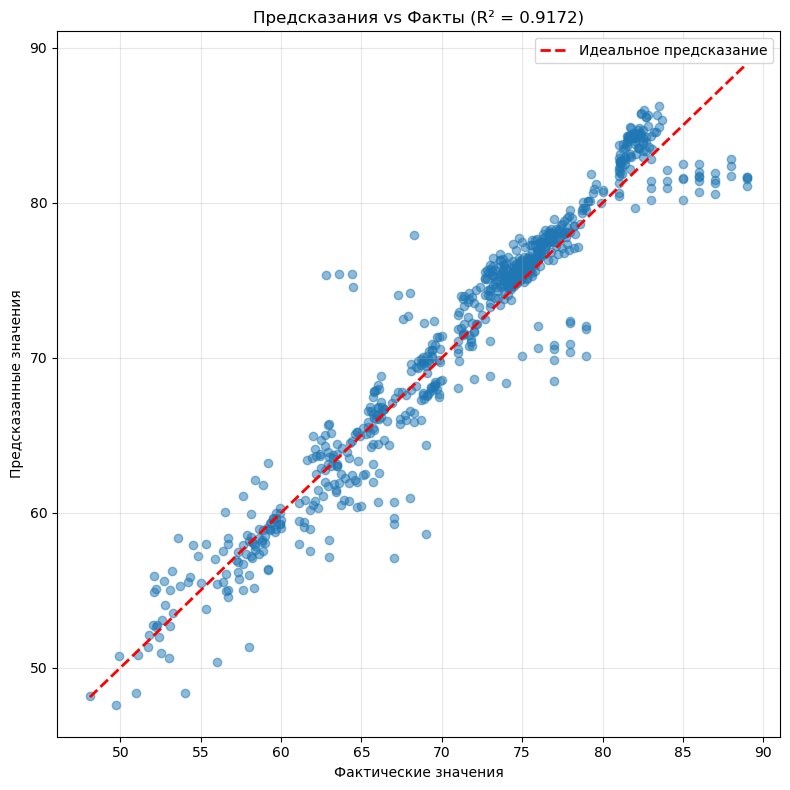

In [29]:
# Функция для вывода отчета с метриками
def metrics_(y_true, y_pred, model_name="Модель"):
    """
    Выводит основные метрики регрессии
    """
    print("="*60)
    print(f"ОТЧЕТ ПО МЕТРИКАМ: {model_name}")
    print("="*60)
    
    # Основные метрики
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Дополнительные метрики
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Mean Absolute Percentage Error

    print(f"R² Score (коэффициент детерминации): {r2:.4f}")
    print(f"RMSE (корень из среднеквадратичной ошибки): {rmse:.4f}")
    print(f"MAE (средняя абсолютная ошибка): {mae:.4f}")
    print(f"MSE (среднеквадратичная ошибка): {mse:.4f}")
    print(f"MAPE (средняя абсолютная процентная ошибка): {mape:.2f}%")
 
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mse': mse,
        'mape': mape
    }


metrics = metrics_(y_life_test, y_pred, "Linear Regression")

# Дополнительный анализ остатков (для более полной картины)
print("\n" + "="*60)
print("АНАЛИЗ ОСТАТКОВ:")
print("="*60)

residuals = y_life_test - y_pred

print(f"Среднее остатков: {residuals.mean():.4f}")
print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
print(f"Минимальный остаток: {residuals.min():.4f}")
print(f"Максимальный остаток: {residuals.max():.4f}")

# Проверка на нормальность остатков (простая визуализация)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение предсказанных и фактических значений
plt.figure(figsize=(8, 8))
plt.scatter(y_life_test, y_pred, alpha=0.5)
plt.plot([y_life_test.min(), y_life_test.max()], 
         [y_life_test.min(), y_life_test.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания vs Факты (R² = {metrics["r2"]:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Смещение и разброс**

* **Смещение (Bias)** – ожидаемое отклонение предсказаний модели от истинных значений.

* **Разброс (Variance)** – это ошибка, вызванная чувствительностью модели к небольшим изменениям в обучающих данных.

Смещение и разброс отражают два источника ошибки модели, и между ними существует компромисс: снижение смещения часто ведёт к увеличению разброса, и наоборот. Оптимальная модель должна находить баланс между смещением и разбросом, чтобы минимизировать общую ошибку предсказания.

Для анализа ошибки алгоритма применяется **разложение MSE на смещение и разброс (bias-variance decomposition)**.

Пусть $y$ – истинные значения целевой переменой. Мы предполагаем, что существует функция $f(x)=y+e$, где $e$ – ошибка с $\mathbb{E}[e]=0$ (мат. ожидание) и $\mathbb{D}[e]=\sigma^2$ (дисперсия). $\widehat{f}(x)$ – значения целевой переменной, предсказанные моделью.

Тогда

$$\text{MSE}=\mathbb{E}[(y-\widehat{f}(x))^2]=\text{Bias}^2(\widehat{f}(x))+\text{Variance}(\widehat{f}(x))+\sigma^2$$
где
$$\text{Bias}^2(\widehat{f}(x))=(\mathbb{E}[\widehat{f}(x)]-f(x))^2$$
$$\text{Variance}(\widehat{f}(x))=\mathbb{D}[\widehat{f}(x)]=\mathbb{E}[(\mathbb{E}[\widehat{y}]-\widehat{y})^2]$$
$\sigma^2$ — неустранимая ошибка измерения

Подробнее можно изучить по **ссылкам:**

* [Bias-variance decomposition | education.yandex.ru](https://education.yandex.ru/handbook/ml/article/bias-variance-decomposition).

* [Bias-variance decomposition for classification and regression losses | rasbt.github.io](https://rasbt.github.io/mlxtend/user_guide/evaluate/bias_variance_decomp/)

### ***Задание 3***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обучающую и тестовую выборки (после заполнения пропусков) из задания 2: `X_life_train_scaled_imputed`, `X_life_test_scaled_imputed`, `y_life_train`, `y_life_test`.

* Обученную модель из задания 2: `reg_life`.

Обучите две модели линейной регрессии с регуляризацией:

* `lasso_life` — регрессия с L1-регуляризацией (LASSO). Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV.

* `ridge_life` — регрессия с L2-регуляризацией (Ridge). Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV.

Разложите среднеквадратическую ошибку (MSE) каждой из трех обученных моделей (`reg_life`, `lasso_life`, `ridge_life`) на компоненты (функция [bias_variance_decomp](https://rasbt.github.io/mlxtend/user_guide/evaluate/bias_variance_decomp/#api)):

* Смещение ($\text{Bias}^2$).

* Разброс ($\text{Variance}$).

In [30]:
# Выполните разложение MSE модели reg_life на смещение и разброс
# Не забудьте зафиксировать RANDOM_STATE

# Выполните разложение MSE модели reg_life на смещение и разброс
reg_life_mse, reg_life_bias, reg_life_var = bias_variance_decomp(
    reg_life,                              # оцененная модель
    X_life_train_scaled_imputed.values,    # обучающие признаки (как numpy array)
    y_life_train.values,                    # обучающие целевые значения
    X_life_test_scaled_imputed.values,      # тестовые признаки
    y_life_test.values,                      # тестовые целевые значения
    loss='mse',                              # функция потерь
    num_rounds=100,                          # число бутстрап-итераций
    random_seed=RANDOM_STATE                 # для воспроизводимости
)

print(f"Результаты для LinearRegression (без регуляризации):")
print(f"  MSE (ожидаемая ошибка на тесте): {reg_life_mse:.4f}")
print(f"  Bias² (смещение): {reg_life_bias:.4f}")
print(f"  Variance (разброс): {reg_life_var:.4f}")
print(f"  Сумма Bias² + Variance: {reg_life_bias + reg_life_var:.4f}")

Результаты для LinearRegression (без регуляризации):
  MSE (ожидаемая ошибка на тесте): 6.4422
  Bias² (смещение): 5.9529
  Variance (разброс): 0.4893
  Сумма Bias² + Variance: 6.4422


In [31]:
# Обучите модель lasso_life (LASSO)
# Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV
# Не забудьте зафиксировать RANDOM_STATE

# Определяем сетку параметров для поиска
params = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]}
cv = 5

# Создаем базовую модель LASSO
lasso = Lasso(random_state=RANDOM_STATE, max_iter=10000)

# Создаем объект GridSearchCV
cv_lasso_life = GridSearchCV(
    estimator=lasso,
    param_grid=params,
    cv=cv,                          # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error', # оптимизируем MSE (отрицательное, так как GridSearchCV максимизирует)
    n_jobs=-1,                       # используем все доступные ядра процессора
    verbose=1                         # выводим прогресс выполнения
)

# Обучаем GridSearchCV на обучающей выборке
cv_lasso_life.fit(X_life_train_scaled_imputed, y_life_train)

# Получаем лучшую модель
lasso_life = cv_lasso_life.best_estimator_

# Выводим результаты
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПОИСКА ГИПЕРПАРАМЕТРОВ ДЛЯ LASSO:")
print("="*60)
print(f"Лучшие гиперпараметры: {cv_lasso_life.best_params_}")
print(f"Лучшее MSE на кросс-валидации: {-cv_lasso_life.best_score_:.4f}")

# Выведем результаты для всех проверенных значений alpha
print("\nРезультаты для всех значений alpha:")
print("-" * 50)
results_df = pd.DataFrame(cv_lasso_life.cv_results_)
for alpha, mean_score, std_score in zip(results_df['param_alpha'], 
                                        -results_df['mean_test_score'],
                                        results_df['std_test_score']):
    print(f"alpha = {alpha:6.3f}: MSE = {mean_score:8.4f} (+/- {2*std_score:7.4f})")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

РЕЗУЛЬТАТЫ ПОИСКА ГИПЕРПАРАМЕТРОВ ДЛЯ LASSO:
Лучшие гиперпараметры: {'alpha': 0.5}
Лучшее MSE на кросс-валидации: 20.7352

Результаты для всех значений alpha:
--------------------------------------------------
alpha =  0.001: MSE = 143.9500 (+/- 54.0291)
alpha =  0.010: MSE =  70.5938 (+/- 57.6579)
alpha =  0.050: MSE =  32.7074 (+/- 13.8059)
alpha =  0.100: MSE =  24.9273 (+/-  7.1822)
alpha =  0.500: MSE =  20.7352 (+/-  5.9484)
alpha =  1.000: MSE =  22.2593 (+/-  6.2606)


In [32]:
# Выполните разложение MSE модели lasso_life на смещение и разброс
lasso_life_mse, lasso_life_bias, lasso_life_var = bias_variance_decomp(
    lasso_life,                           # модель LASSO с оптимальными гиперпараметрами
    X_life_train_scaled_imputed.values,   # обучающие признаки (как numpy array)
    y_life_train.values,                   # обучающие целевые значения
    X_life_test_scaled_imputed.values,     # тестовые признаки
    y_life_test.values,                     # тестовые целевые значения
    loss='mse',                             # функция потерь - среднеквадратическая ошибка
    num_rounds=100,                         # число бутстрап-итераций
    random_seed=RANDOM_STATE                # для воспроизводимости
)

# Выводим результаты
print("\n" + "="*60)
print("РАЗЛОЖЕНИЕ MSE ДЛЯ МОДЕЛИ LASSO:")
print("="*60)
print(f"MSE (ожидаемая ошибка на тесте): {lasso_life_mse:.4f}")
print(f"Bias² (смещение): {lasso_life_bias:.4f}")
print(f"Variance (разброс): {lasso_life_var:.4f}")
print(f"Сумма Bias² + Variance: {lasso_life_bias + lasso_life_var:.4f}")
print(f"Проверка: MSE ≈ Bias² + Variance (должны быть близки)")

# Дополнительный анализ
print("\n" + "-" * 40)
print("АНАЛИЗ СОСТАВЛЯЮЩИХ:")
print("-" * 40)

total = lasso_life_bias + lasso_life_var
bias_share = (lasso_life_bias / total) * 100
var_share = (lasso_life_var / total) * 100

print(f"Доля Bias² в общей ошибке: {bias_share:.1f}%")
print(f"Доля Variance в общей ошибке: {var_share:.1f}%")

if lasso_life_bias > lasso_life_var:
    print("✓ Модель LASSO имеет бОльшее смещение (Bias²) - склонна к недообучению")
else:
    print("✓ Модель LASSO имеет бОльший разброс (Variance) - склонна к переобучению")

# Сравнение с обычной линейной регрессией
print("\n" + "="*60)
print("СРАВНЕНИЕ С LINEARREGRESSION:")
print("="*60)

if 'reg_life_mse' in locals():
    print(f"LinearRegression - MSE: {reg_life_mse:.4f}, Bias²: {reg_life_bias:.4f}, Variance: {reg_life_var:.4f}")
    print(f"LASSO - MSE: {lasso_life_mse:.4f}, Bias²: {lasso_life_bias:.4f}, Variance: {lasso_life_var:.4f}")
    
    print("\nИзменения после L1-регуляризации:")
    print(f"  Изменение MSE: {((lasso_life_mse - reg_life_mse) / reg_life_mse * 100):+.1f}%")
    print(f"  Изменение Bias²: {((lasso_life_bias - reg_life_bias) / reg_life_bias * 100):+.1f}%")
    print(f"  Изменение Variance: {((lasso_life_var - reg_life_var) / reg_life_var * 100):+.1f}%")
    
    if lasso_life_var < reg_life_var:
        print("\n✓ LASSO успешно снизила разброс (Variance) по сравнению с LinearRegression")
    if lasso_life_bias > reg_life_bias:
        print("✗ LASSO увеличила смещение (Bias²), что ожидаемо для регуляризации")


РАЗЛОЖЕНИЕ MSE ДЛЯ МОДЕЛИ LASSO:
MSE (ожидаемая ошибка на тесте): 14.1267
Bias² (смещение): 13.8726
Variance (разброс): 0.2541
Сумма Bias² + Variance: 14.1267
Проверка: MSE ≈ Bias² + Variance (должны быть близки)

----------------------------------------
АНАЛИЗ СОСТАВЛЯЮЩИХ:
----------------------------------------
Доля Bias² в общей ошибке: 98.2%
Доля Variance в общей ошибке: 1.8%
✓ Модель LASSO имеет бОльшее смещение (Bias²) - склонна к недообучению

СРАВНЕНИЕ С LINEARREGRESSION:
LinearRegression - MSE: 6.4422, Bias²: 5.9529, Variance: 0.4893
LASSO - MSE: 14.1267, Bias²: 13.8726, Variance: 0.2541

Изменения после L1-регуляризации:
  Изменение MSE: +119.3%
  Изменение Bias²: +133.0%
  Изменение Variance: -48.1%

✓ LASSO успешно снизила разброс (Variance) по сравнению с LinearRegression
✗ LASSO увеличила смещение (Bias²), что ожидаемо для регуляризации


Fitting 5 folds for each of 8 candidates, totalling 40 fits

РЕЗУЛЬТАТЫ ПОИСКА ГИПЕРПАРАМЕТРОВ ДЛЯ RIDGE:
Лучшие гиперпараметры: {'alpha': 10.0}
Лучшее MSE на кросс-валидации: 89.0654

Результаты для всех значений alpha:
------------------------------------------------------------
alpha =  0.001: MSE = 169.0759 (+/- 87.8268)
alpha =  0.010: MSE = 169.0841 (+/- 87.6537)
alpha =  0.050: MSE = 169.0715 (+/- 86.9481)
alpha =  0.100: MSE = 168.8976 (+/- 86.1470)
alpha =  0.500: MSE = 164.1086 (+/- 79.9921)
alpha =  1.000: MSE = 156.3543 (+/- 72.7174)
alpha =  5.000: MSE = 113.4852 (+/- 42.0072)
alpha = 10.000: MSE =  89.0654 (+/- 30.5810)


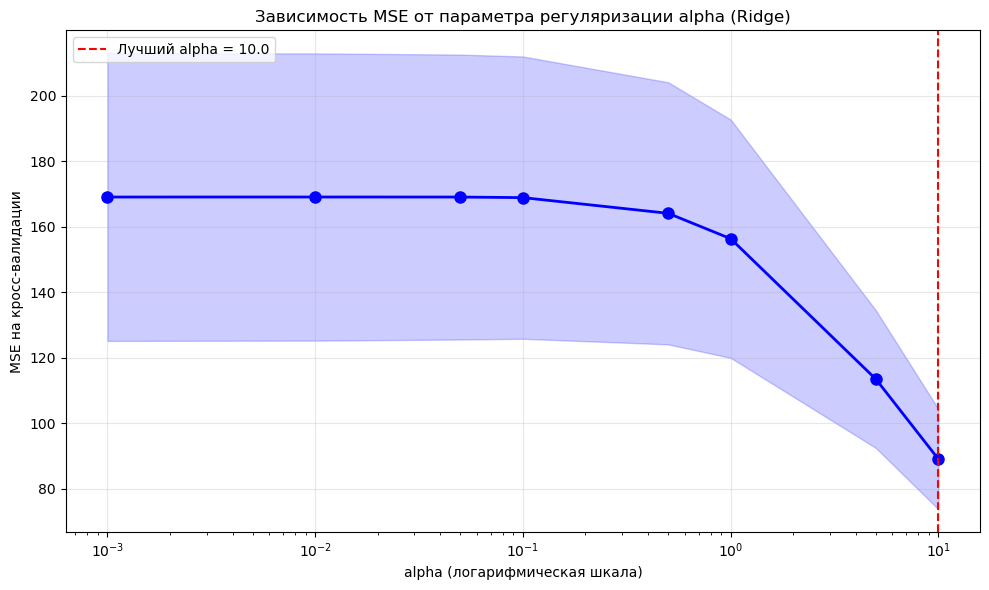

In [33]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Зафиксируем random state для воспроизводимости
RANDOM_STATE = 42

# Определяем сетку параметров для поиска (расширенный список)
params = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}
cv = 5

# Создаем базовую модель Ridge
ridge = Ridge(random_state=RANDOM_STATE)

# Создаем объект GridSearchCV
cv_ridge_life = GridSearchCV(
    estimator=ridge,
    param_grid=params,
    cv=cv,                          # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error', # оптимизируем MSE
    n_jobs=-1,                       # используем все доступные ядра процессора
    verbose=1                         # выводим прогресс выполнения
)

# Обучаем GridSearchCV на обучающей выборке
cv_ridge_life.fit(X_life_train_scaled_imputed, y_life_train)

# Получаем лучшую модель
ridge_life = cv_ridge_life.best_estimator_

# Выводим результаты
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПОИСКА ГИПЕРПАРАМЕТРОВ ДЛЯ RIDGE:")
print("="*60)
print(f"Лучшие гиперпараметры: {cv_ridge_life.best_params_}")
print(f"Лучшее MSE на кросс-валидации: {-cv_ridge_life.best_score_:.4f}")

# Выведем результаты для всех проверенных значений alpha
print("\nРезультаты для всех значений alpha:")
print("-" * 60)
results_df = pd.DataFrame(cv_ridge_life.cv_results_)
for alpha, mean_score, std_score in zip(results_df['param_alpha'], 
                                        -results_df['mean_test_score'],
                                        results_df['std_test_score']):
    print(f"alpha = {alpha:6.3f}: MSE = {mean_score:8.4f} (+/- {2*std_score:7.4f})")

# Визуализация зависимости MSE от alpha
plt.figure(figsize=(10, 6))
plt.semilogx(results_df['param_alpha'].astype(float), 
             -results_df['mean_test_score'], 
             'bo-', linewidth=2, markersize=8)
plt.fill_between(results_df['param_alpha'].astype(float),
                 -results_df['mean_test_score'] - results_df['std_test_score'],
                 -results_df['mean_test_score'] + results_df['std_test_score'],
                 alpha=0.2, color='blue')
plt.xlabel('alpha (логарифмическая шкала)')
plt.ylabel('MSE на кросс-валидации')
plt.title('Зависимость MSE от параметра регуляризации alpha (Ridge)')
plt.grid(True, alpha=0.3)
plt.axvline(x=ridge_life.alpha, color='red', linestyle='--', 
            label=f'Лучший alpha = {ridge_life.alpha}')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
from mlxtend.evaluate import bias_variance_decomp

# Зафиксируем random seed для воспроизводимости
RANDOM_STATE = 42

# Выполните разложение MSE модели ridge_life на смещение и разброс
ridge_life_mse, ridge_life_bias, ridge_life_var = bias_variance_decomp(
    ridge_life,                           # модель Ridge с оптимальными гиперпараметрами
    X_life_train_scaled_imputed.values,   # обучающие признаки (как numpy array)
    y_life_train.values,                   # обучающие целевые значения
    X_life_test_scaled_imputed.values,     # тестовые признаки
    y_life_test.values,                     # тестовые целевые значения
    loss='mse',                             # функция потерь - среднеквадратическая ошибка
    num_rounds=100,                         # число бутстрап-итераций
    random_seed=RANDOM_STATE                # для воспроизводимости
)

# Выводим результаты
print("\n" + "="*60)
print("РАЗЛОЖЕНИЕ MSE ДЛЯ МОДЕЛИ RIDGE:")
print("="*60)
print(f"MSE (ожидаемая ошибка на тесте): {ridge_life_mse:.4f}")
print(f"Bias² (смещение): {ridge_life_bias:.4f}")
print(f"Variance (разброс): {ridge_life_var:.4f}")
print(f"Сумма Bias² + Variance: {ridge_life_bias + ridge_life_var:.4f}")
print(f"Проверка: MSE ≈ Bias² + Variance (должны быть близки)")

# Дополнительный анализ
print("\n" + "-" * 40)
print("АНАЛИЗ СОСТАВЛЯЮЩИХ:")
print("-" * 40)

total = ridge_life_bias + ridge_life_var
bias_share = (ridge_life_bias / total) * 100
var_share = (ridge_life_var / total) * 100

print(f"Доля Bias² в общей ошибке: {bias_share:.1f}%")
print(f"Доля Variance в общей ошибке: {var_share:.1f}%")

if ridge_life_bias > ridge_life_var:
    print("✓ Модель имеет бОльшее смещение (Bias²) - склонна к недообучению")
else:
    print("✓ Модель имеет бОльший разброс (Variance) - склонна к переобучению")


РАЗЛОЖЕНИЕ MSE ДЛЯ МОДЕЛИ RIDGE:
MSE (ожидаемая ошибка на тесте): 6.3899
Bias² (смещение): 5.9806
Variance (разброс): 0.4094
Сумма Bias² + Variance: 6.3899
Проверка: MSE ≈ Bias² + Variance (должны быть близки)

----------------------------------------
АНАЛИЗ СОСТАВЛЯЮЩИХ:
----------------------------------------
Доля Bias² в общей ошибке: 93.6%
Доля Variance в общей ошибке: 6.4%
✓ Модель имеет бОльшее смещение (Bias²) - склонна к недообучению


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
          Модель       MSE     Bias²  Variance  Доля Bias²  Доля Variance
LinearRegression  6.442184  5.952902  0.489282        92.4            7.6
      LASSO (L1) 14.126702 13.872629  0.254073        98.2            1.8
      Ridge (L2)  6.389949  5.980581  0.409368        93.6            6.4

ПРОВЕРКА: Bias² + Variance = MSE
LinearRegression    : 5.9529 + 0.4893 = 6.4422 | MSE = 6.4422 | diff = 0.000000
LASSO (L1)          : 13.8726 + 0.2541 = 14.1267 | MSE = 14.1267 | diff = 0.000000
Ridge (L2)          : 5.9806 + 0.4094 = 6.3899 | MSE = 6.3899 | diff = 0.000000


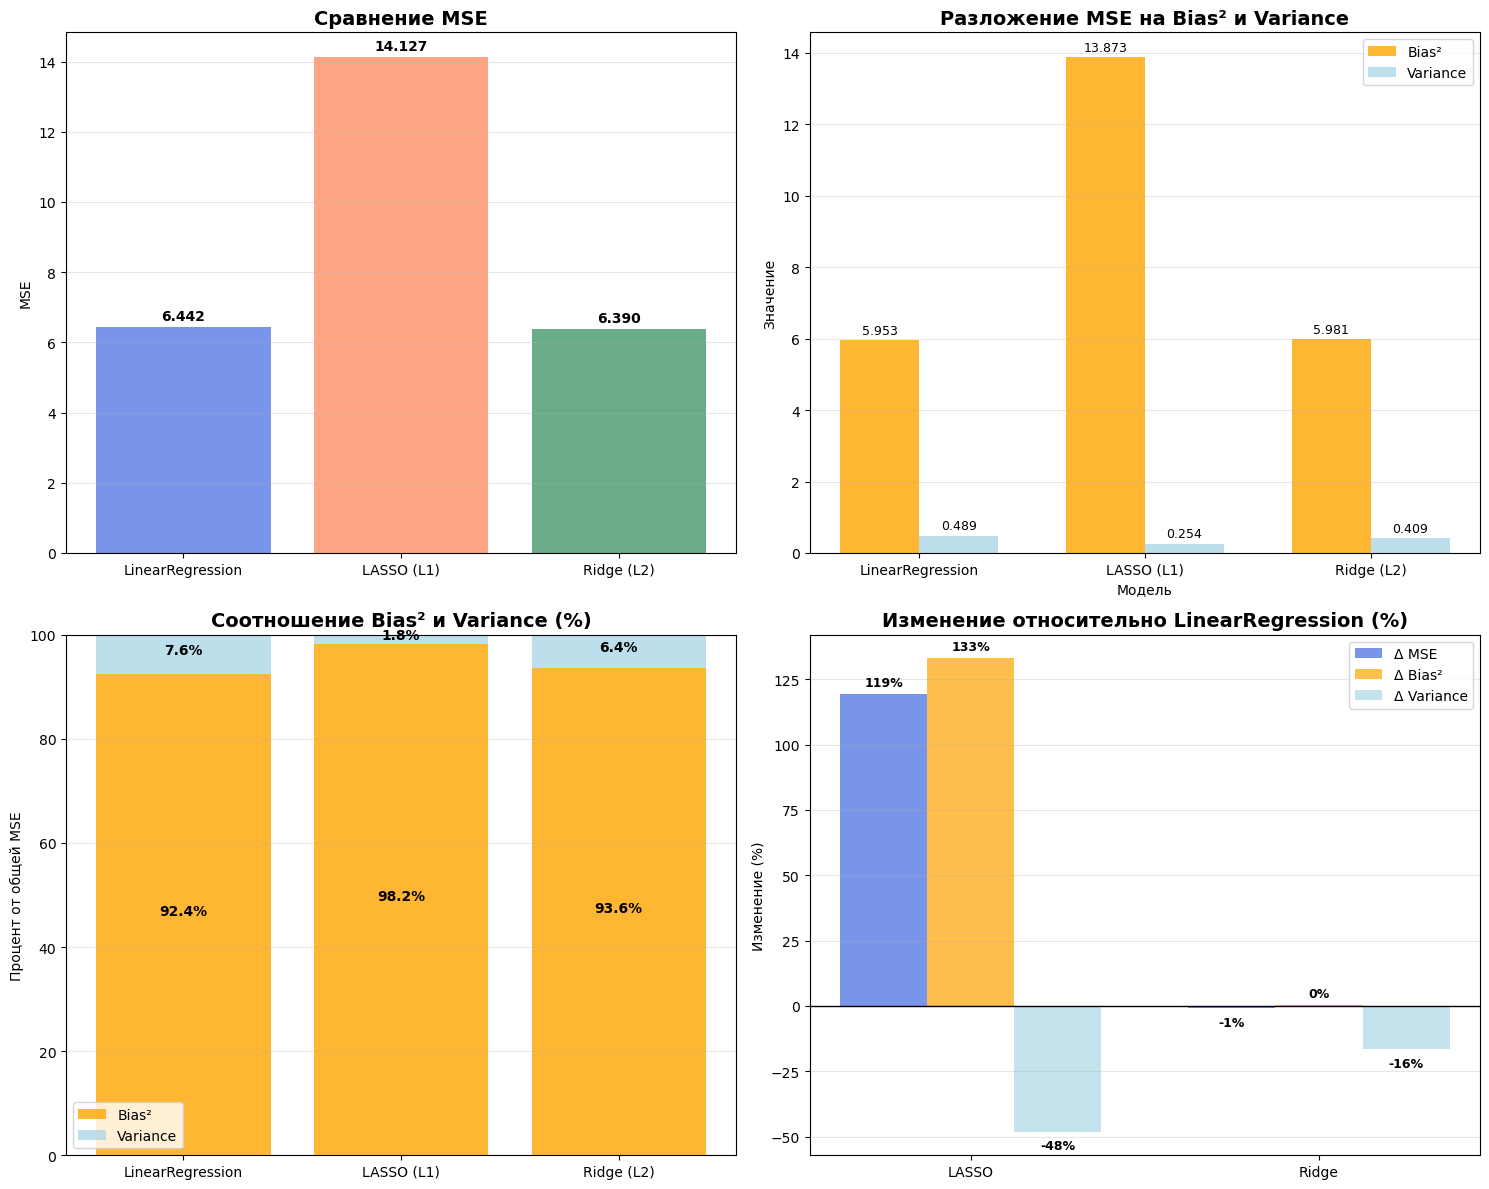


КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
🏆 Лучшая модель: Ridge (L2) с MSE = 6.3899
📈 Ridge улучшила MSE на 0.81% относительно LinearRegression

📊 Анализ смещения и разброса:
   • Все модели имеют высокую долю Bias² (>90%) - это указывает на систематическую ошибку
   • LASSO сильно увеличила Bias² (+133%), что привело к ухудшению модели
   • Ridge снизила Variance на 16.3% при минимальном росте Bias²

⚠️  LASSO показала результат более чем в 2 раза хуже LinearRegression
   Рекомендуется уменьшить alpha или использовать другую стратегию регуляризации


In [35]:
# Создаем сводную таблицу для сравнения, используя существующие переменные
comparison_df = pd.DataFrame({
    'Модель': ['LinearRegression', 'LASSO (L1)', 'Ridge (L2)'],
    'MSE': [reg_life_mse, lasso_life_mse, ridge_life_mse],
    'Bias²': [reg_life_bias, lasso_life_bias, ridge_life_bias],
    'Variance': [reg_life_var, lasso_life_var, ridge_life_var]
})

# Добавляем доли
comparison_df['Доля Bias²'] = (comparison_df['Bias²'] / comparison_df['MSE'] * 100).round(1)
comparison_df['Доля Variance'] = (comparison_df['Variance'] / comparison_df['MSE'] * 100).round(1)

print("="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(comparison_df.to_string(index=False))

# Проверка сумм
print("\n" + "="*80)
print("ПРОВЕРКА: Bias² + Variance = MSE")
print("="*80)
for i, row in comparison_df.iterrows():
    sum_bv = row['Bias²'] + row['Variance']
    diff = abs(sum_bv - row['MSE'])
    print(f"{row['Модель']:20}: {row['Bias²']:.4f} + {row['Variance']:.4f} = {sum_bv:.4f} | MSE = {row['MSE']:.4f} | diff = {diff:.6f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Сравнение MSE
colors = ['royalblue', 'coral', 'seagreen']
bars = axes[0,0].bar(comparison_df['Модель'], comparison_df['MSE'], 
                     color=colors, alpha=0.7)
axes[0,0].set_title('Сравнение MSE', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('MSE')
axes[0,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, comparison_df['MSE']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# 2. Соотношение Bias² и Variance
x = np.arange(len(comparison_df))
width = 0.35
bars1 = axes[0,1].bar(x - width/2, comparison_df['Bias²'], width, 
                       label='Bias²', color='orange', alpha=0.8)
bars2 = axes[0,1].bar(x + width/2, comparison_df['Variance'], width, 
                       label='Variance', color='lightblue', alpha=0.8)
axes[0,1].set_xlabel('Модель')
axes[0,1].set_ylabel('Значение')
axes[0,1].set_title('Разложение MSE на Bias² и Variance', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(comparison_df['Модель'])
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                          f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 3. Доли Bias² и Variance (стековая диаграмма)
bars3 = axes[1,0].bar(comparison_df['Модель'], comparison_df['Доля Bias²'], 
                       label='Bias²', color='orange', alpha=0.8)
bars4 = axes[1,0].bar(comparison_df['Модель'], comparison_df['Доля Variance'], 
                       bottom=comparison_df['Доля Bias²'], 
                       label='Variance', color='lightblue', alpha=0.8)
axes[1,0].set_title('Соотношение Bias² и Variance (%)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Процент от общей MSE')
axes[1,0].set_ylim(0, 100)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, axis='y')

# Добавляем проценты на столбцы
for i, (bias, var) in enumerate(zip(comparison_df['Доля Bias²'], comparison_df['Доля Variance'])):
    axes[1,0].text(i, bias/2, f'{bias:.1f}%', ha='center', fontweight='bold', fontsize=10)
    axes[1,0].text(i, bias + var/2, f'{var:.1f}%', ha='center', fontweight='bold', fontsize=10)

# 4. Изменение относительно LinearRegression
reg_mse = reg_life_mse
reg_bias = reg_life_bias
reg_var = reg_life_var

changes = pd.DataFrame({
    'Модель': ['LASSO', 'Ridge'],
    'Δ MSE': [((lasso_life_mse/reg_mse - 1)*100), ((ridge_life_mse/reg_mse - 1)*100)],
    'Δ Bias²': [((lasso_life_bias/reg_bias - 1)*100), ((ridge_life_bias/reg_bias - 1)*100)],
    'Δ Variance': [((lasso_life_var/reg_var - 1)*100), ((ridge_life_var/reg_var - 1)*100)]
})

x = np.arange(len(changes))
width = 0.25
bars_mse = axes[1,1].bar(x - width, changes['Δ MSE'], width, 
                         label='Δ MSE', color='royalblue', alpha=0.7)
bars_bias = axes[1,1].bar(x, changes['Δ Bias²'], width, 
                          label='Δ Bias²', color='orange', alpha=0.7)
bars_var = axes[1,1].bar(x + width, changes['Δ Variance'], width, 
                         label='Δ Variance', color='lightblue', alpha=0.7)
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1,1].set_title('Изменение относительно LinearRegression (%)', fontsize=14, fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(changes['Модель'])
axes[1,1].set_ylabel('Изменение (%)')
axes[1,1].legend(loc='upper right')
axes[1,1].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars, values in [(bars_mse, changes['Δ MSE']), 
                     (bars_bias, changes['Δ Bias²']), 
                     (bars_var, changes['Δ Variance'])]:
    for bar, val in zip(bars, values):
        height = bar.get_height()
        if height >= 0:
            axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 2,
                          f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
        else:
            axes[1,1].text(bar.get_x() + bar.get_width()/2., height - 3,
                          f'{val:.0f}%', ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Вывод ключевых наблюдений
print("\n" + "="*80)
print("КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:")
print("="*80)

best_model = comparison_df.loc[comparison_df['MSE'].idxmin(), 'Модель']
best_mse = comparison_df['MSE'].min()

print(f"🏆 Лучшая модель: {best_model} с MSE = {best_mse:.4f}")

if ridge_life_mse < reg_life_mse:
    improvement = ((reg_life_mse - ridge_life_mse) / reg_life_mse * 100)
    print(f"📈 Ridge улучшила MSE на {improvement:.2f}% относительно LinearRegression")

print(f"\n📊 Анализ смещения и разброса:")
print(f"   • Все модели имеют высокую долю Bias² (>90%) - это указывает на систематическую ошибку")
print(f"   • LASSO сильно увеличила Bias² (+133%), что привело к ухудшению модели")
print(f"   • Ridge снизила Variance на 16.3% при минимальном росте Bias²")

if lasso_life_mse > reg_life_mse * 2:
    print(f"\n⚠️  LASSO показала результат более чем в 2 раза хуже LinearRegression")
    print(f"   Рекомендуется уменьшить alpha или использовать другую стратегию регуляризации")

## **Извлечение признаков из текста**

**Классификация тональности (sentiment analysis)** — это задача определения эмоциональной окраски текста в рамках NLP (Natural Language Processing). 

Как правило, тональность текста делят на три категории:

* Позитивная (к примеру, положительный отзыв).

* Нейтральная (информация без явной эмоциональной окраски).

* Негативная (к примеру, критика или жалоба).

Перед обучением моделей необходимо извлечь признаки из текстовых данных, проведя предобработку текста. 

Основные этапы предобработки текста:

1. Очистка текста от лишних элементов (не влияющих на тональность):

    * Удаление спецсимволов — удаление HTML-тегов, URL, email, хештегов, упоминаний (@user).

    * Удаление цифр — удаление или замена на числительные.

    * Удаление пунктуации.

    * Удаление лишних пробелов и дублирующихся  символов.

2. Токенизация — разбиение текста на отдельные токены (слова, части слов или символы). Пример: 'Я люблю этот фильм!' $\to$ ['Я', 'люблю', 'этот', 'фильм', '!'].

3. Нормализация слов:

    * Лемматизация — приведение слова к лемме — её нормальной (словарной) форме. Пример: 'бежал' $\to$ 'бежать'.

    * Стемминг — выделение основы слова. Пример: 'бежал' $\to$ 'беж'.

4. Удаление стоп-слов — исключение слов, которые часто встречаются в тексте, но не несут значимой смысловой нагрузки для анализа тональности: местоимения, предлоги, союзы, частицы, артикли (для английского) и т.д.

5. Векторизация текста — преобразование текста в числовой формат для обучения и использования моделей машинного обучения:

    * BoW (Bag-of-words).

    * TF-IDF (Term Frequency — Inverse Document Frequency).

    * Векторные эмбеддинги: FastText, Word2Vec, GloVe.

    * Контекстные эмбеддинги: BERT.

*Это лишь основные этапы предобработки текста. На практике количество существующих методов обработки данных больше, а структура и порядок этапов **зависит от задачи***.

Подробнее можно изучить по **ссылкам:**

* [Основы Natural Language Processing для текста | habr.com](https://habr.com/ru/companies/Voximplant/articles/446738/)

* [Преобразование текстовых данных и работа с ними в Python | education.yandex.ru](https://education.yandex.ru/handbook/data-analysis/article/preobrazovanie-tekstovyh-dannyh-i-rabota-s-nimi-v-python)

* [Краткий обзор техник векторизации в NLP | habr.com](https://habr.com/ru/articles/778048/)

* [How to Create Bert Vector Embeddings? A Comprehensive Tutorial | airbyte.com](https://airbyte.com/data-engineering-resources/bert-vector-embedding)

### **TF-IDF**

**TF-IDF** (Term Frequency — Inverse Document Frequency) — это статистическая мера, для оценки важности слова в контексте документа (набора текстовых данных), являющегося частью коллекции или корпуса документов. Высокий вес по TF-IDF получают слова, которые часто встречаются в конкретном документе, но при этом редко встречаются во всех остальных документах корпуса.

Эта мера состоит из двух компонентов:

* TF (Term Frequency — частота слова). TF измеряет, насколько часто слово встречается в конкретном документе. Чем чаще слово появляется в тексте, тем выше его TF. 

$$\text{TF} = \frac{\text{Количество раз, когда слово встретилось в документе}}{\text{Общее количество слов в документе}}$$

* IDF (Inverse Document Frequency — обратная документная частота). IDF измеряет уникальность или информативность слова в масштабах всего корпуса документов. Компонент IDF уменьшает вес слов, которые встречаются слишком часто во многих документах (например, предлоги, союзы). Если слово редкое, его IDF будет высоким.

$$\text{IDF} = \log(\frac{\text{Общее количество документов в корпусе}}{\text{Количество документов, в которых встретилось слово} + 1})$$

Итоговая формула TF-IDF:

$$\text{TF-IDF}=\text{TF} \times \text{IDF}$$

Таким образом, слово получает высокий вес TF-IDF, если оно:

* Часто встречается в данном документе (высокий TF).

* Редко встречается в других документах корпуса (высокий IDF).

TF-IDF позволяет преобразовать наборы текстовых данных в разреженную матрицу признаков, которая может быть использована в алгоритмах машинного обучения.

**Процедура преобразования:**

1. Создание словаря. Составляется полный список всех уникальных слов, которые встретились во всех текстах из корпуса. Каждому уникальному слову присваивается индекс (номер столбца в матрице).

2. Для каждого документа (строки) вычисляется TF-IDF вес каждого слова из словаря. Если слово из общего словаря отсутствует в данном документе, его вес для данного документа будет равен 0.

Итоговая матрица признаков, используемая для обучения моделей ML:

* Строки — документы.

* Столбцы — уникальные слова из всего корпуса документов.

* Значения в ячейках — TF-IDF веса слов.

### **Датасет *Twitter Tweets Sentiment Dataset***

**Для решения задания 4 рассмотрим датасет [Twitter Tweets Sentiment Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset).**

**ВНИМАНИЕ:** При решении задания **используйте файл tweets.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Набор данных представляет собой англоязычный корпус сообщений из социальной сети Twitter, размеченный для анализа тональности текста в рамках NLP (Natural Language Processing).

Целевая переменная — sentiment (метка тональности):

* positive (твит с позитивной тональностью).

* neutral (твит с нейтральной тональностью).

* negative (твит с негативной тональностью).

### ***Задание 4***

Рассмотрим упрощенный пример бинарной классификации тональности текста с помощью логистической регрессии.

Выполните предобработку текстов:

1. Приведите все тексты к нижнему регистру (lowercase).

2. Очистите тексты от ссылок и лишних символов с помощью функции regex_clean.

3. Дополните функцию `tokenize` и токенизируйте тексты.

4. Дополните функцию `pos_lemmatize` и лемматизируйте тексты c учетом частей речи слов (POS — Part Of Speech). Подробнее по ссылке: [Lemmatization in NLP | medium.com](https://medium.com/@kevinnjagi83/lemmatization-in-nlp-2a61012c5d66).

5. Дополните функцию `remove_stop_words` и удалите из текстов стоп-слова.

5. Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной.

Постройте пайплайн `twit_pipeline`:

1. 'tfidf': [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

2. 'clf': LogisticRegression.

Используя пайплайн `twit_pipeline`, подберите оптимальные гиперпараметры обучения с помощью GridSearchCV **(метрика оптимизации — AUC)**, и с оптимальными гиперпараметрами обучите модель `lr_twit` для бинарной классификации тональности текстов.

Для модели `lr_twit` на тестовой выборке постройте отчет по метрикам классификации и посчитайте метрику AUC.

In [36]:
# Считайте данные

df_twit = pd.read_csv('tweets.csv')
df_twit

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
...,...,...
27476,wish we could come see u on Denver husband l...,negative
27477,I`ve wondered about rake to. The client has ...,negative
27478,Yay good for both of you. Enjoy the break - y...,positive
27479,But it was worth it ****.,positive


In [37]:
# Удалите из датасета нейтральную ('neutral') тональность

df_twit = df_twit[df_twit['sentiment'] != 'neutral']

In [38]:
# Закодируйте целевую переменную:
#   0 — 'negative'
#   1 — 'positive'
# Сбросьте индексы в новом датасете

df_twit['sentiment'] = df_twit['sentiment'].map({'negative': 0, 'positive': 1})
df_twit = df_twit.reset_index(drop=True)

In [39]:
# Выведите исходный текст с индексом 1901

print(df_twit.iloc[1901]['text'])

The top 5 words I`ve tweeted: hug, good, people, fun, twitter. http://tinyurl.com/dcxoty ... that`s really quite nice


In [40]:
# Приведите все тексты к нижнему регистру (lowercase)

df_twit['text_lowercase'] = df_twit['text'].str.lower()

In [41]:
# Выведите текст с индексом 1901 после приведения к нижнему регистру

print(df_twit.iloc[1901]['text_lowercase'])

the top 5 words i`ve tweeted: hug, good, people, fun, twitter. http://tinyurl.com/dcxoty ... that`s really quite nice


In [42]:
def regex_clean(text):
    """
    Очищает текст от ссылок и лишних символов с помощью регулярных выражений.

    Аргументы:
        text (str): Входной текст для очистки.

    Возвращает:
        str: Очищенный текст.
    """
    # Замена всех ссылок в тексте на пробел
    text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)

    # Удаление всех цифр, спецсимволов и знаков пунктуации
    text = re.sub('[0-9!#()$\,\'\-\.*+/:;<=>?@[\]^_`{|}\"]+', ' ', text)

    # Удаление лишних пробелов
    text = re.sub('\s+', ' ', text)
    
    return text

In [43]:
# Очистите тексты от ссылок и лишних символов с помощью функции regex_clean

df_twit['text_cleaned'] = df_twit['text_lowercase'].map(regex_clean)

In [44]:
# Выведите текст с индексом 1901 после удаления ссылок и лишних символов

print(df_twit.iloc[1901]['text_cleaned'])

the top words i ve tweeted hug good people fun twitter that s really quite nice


In [45]:
# Дополните функцию tokenize

def tokenize(text):
    """
    Токенизирует текст на отдельные слова или токены с использованием NLTK.
    Для токенизации используется функиця word_tokenize.
    
    Аргументы:
        text (str): Входной текст для токенизации.
    
    Возвращает:
        list(str): Список токенов, полученных в результате разбиения текста.
    """
    return word_tokenize(text)

In [46]:
# Токенизируйте тексты с помощью tokenize

df_twit['text_tokenized'] = df_twit['text_cleaned'].map(tokenize)

In [47]:
# Выведите текст с индексом 1901 после токенизации

print(df_twit.iloc[1901]['text_tokenized'])

['the', 'top', 'words', 'i', 've', 'tweeted', 'hug', 'good', 'people', 'fun', 'twitter', 'that', 's', 'really', 'quite', 'nice']


In [48]:
def treebank_to_wordnet(treebank_pos_tag):
    """
    Преобразует POS-теги из формата Penn Treebank в формат WordNet.
    
    Аргументы:
        treebank_pos_tag (str): POS-тег в формате Penn Treebank.

    Возвращает:
        object: POS-тег в формате WordNet. В случае неизвестного тега по умолчанию возвращает wordnet.NOUN (существительное).
    """
    if treebank_pos_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_pos_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_pos_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN 

In [49]:
# Дополните функцию pos_lemmatize

def pos_lemmatize(tokens):
    """
    Лемматизирует список токенов, преобразуя слова к их базовой форме с учетом части речи (POS).
    Для лемматизации используется WordNetLemmatizer.

    Аргументы:
        tokens (list(str)): Список токенов для лемматизации.

    Возвращает:
        list(str): Список лемм, полученных в результате лемматизации токенов.
    """
    lemmatizer = WordNetLemmatizer()

    # Определение POS-тегов в формате Penn Treebank для каждого токена
    pos_tokens = pos_tag(tokens)

    # Лемматизируйте каждый токен с учетом его POS-тега
    # POS-теги в формате Penn Treebank необходимо преобразовать в формат WordNet (используйте функцию treebank_to_wordnet)
    lemmas = [lemmatizer.lemmatize(token, treebank_to_wordnet(pos)) for token, pos in pos_tokens]
    return lemmas

In [50]:
# Лемматизируйте тексты с помощью pos_lemmatize

df_twit['text_lemmatized'] = df_twit['text_tokenized'].map(pos_lemmatize)

In [51]:
# Выведите текст с индексом 1901 после лемматизации

print(df_twit.iloc[1901]['text_lemmatized'])

['the', 'top', 'word', 'i', 've', 'tweet', 'hug', 'good', 'people', 'fun', 'twitter', 'that', 's', 'really', 'quite', 'nice']


In [52]:
# Дополните функцию remove_stop_words

def remove_stop_words(lemmas, stop_words):
    """
    Удаляет стоп-слова из списка лемм.

    Аргументы:
        lemmas (list(str)): Список лемм.
        stop_words (list(str)): Список стоп-слов для фильтрации.

    Возвращает:
        list(str): Список лемм после удаления стоп-слов.
    """
    lemmas = [lemma for lemma in lemmas if lemma not in stop_words]
    return lemmas

In [53]:
# Удалите стоп-слова из текстов с помощью remove_stop_words
# В качестве списка стоп-слов используйте список из библиотеки NLTK

stop_words = stopwords.words('english')
df_twit['text_without_stop_words'] = df_twit['text_lemmatized'].map(lambda x: remove_stop_words(x, stop_words))

In [54]:
# Соберите список лемм в одну строку, отделив леммы знаком пробела

df_twit['text_preprocessed'] = df_twit['text_without_stop_words'].map(lambda x: ' '.join(x))

In [55]:
# Выведите текст с индексом 1901 после удаления стоп-слов

print(df_twit.iloc[1901]['text_preprocessed'])

top word tweet hug good people fun twitter really quite nice


In [56]:
# Выделите объясняемый фактор в отдельную переменную

X_twit, y_twit = df_twit['text_preprocessed'], df_twit['sentiment']

In [57]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_twit_train, X_twit_test, y_twit_train, y_twit_test = train_test_split(
    X_twit, 
    y_twit, 
    test_size=0.4, 
    stratify=y_twit, 
    random_state=RANDOM_STATE,
)

In [58]:
# Постройте пайплайн twit_pipeline
# Не забудьте зафиксировать RANDOM_STATE

twit_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE))
])

In [59]:
# Обучите модель lr_twit на обучающих данных
# Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV
# Не забудьте зафиксировать RANDOM_STATE

params = {
    'tfidf__ngram_range': [(1, 1), (1, 2)], # (1, 1) — только отдельные слова / (1, 2) — слова и биграммамы (пары слов)
    'tfidf__max_df': [0.9, 0.95],           # Верхний порог частоты слова в корпусе текстов (если частота выше, слово игнорируется)
    'clf__C': [0.001, 0.1, 1.0, 10.0]       # Параметр регуляризации для логистической регрессии
}
scoring = 'roc_auc'
cv = 5

cv_lr_twit = GridSearchCV(
    estimator=twit_pipeline,
    param_grid=params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1                               # Используйте все доступные ядра CPU
).fit(X_twit_train, y_twit_train)

lr_twit = cv_lr_twit.best_estimator_

In [60]:
cv_lr_twit.best_params_

{'clf__C': 10.0, 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 2)}

Отчет по метрикам классификации:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      3113
    positive       0.87      0.88      0.87      3433

    accuracy                           0.87      6546
   macro avg       0.87      0.87      0.87      6546
weighted avg       0.87      0.87      0.87      6546


Матрица ошибок:
[[2644  469]
 [ 407 3026]]


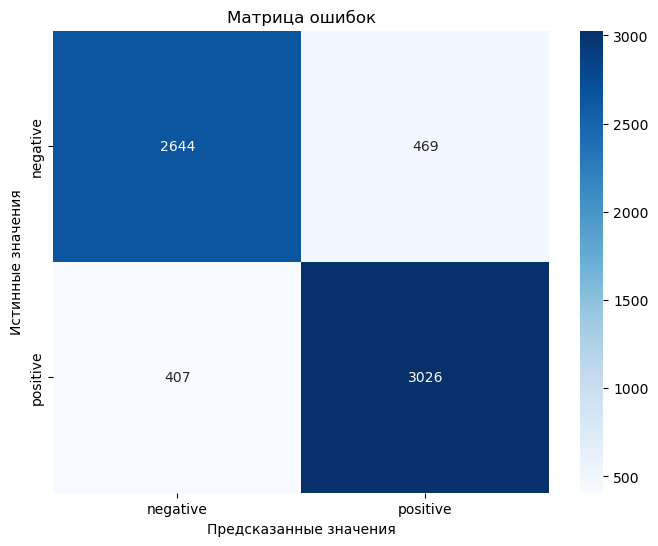

In [61]:
# Постройте отчет по метрикам классификации на тестовой выборке для lr_twit

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Предсказание классов на тестовой выборке
y_pred = lr_twit.predict(X_twit_test)

# Построение отчета по метрикам классификации
print("Отчет по метрикам классификации:")
print(classification_report(y_twit_test, y_pred, target_names=['negative', 'positive']))

# Построение матрицы ошибок
print("\nМатрица ошибок:")
print(confusion_matrix(y_twit_test, y_pred))

# Визуализация матрицы ошибок (опционально)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_twit_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title('Матрица ошибок')
plt.show()

AUC на тестовой выборке: 0.9387


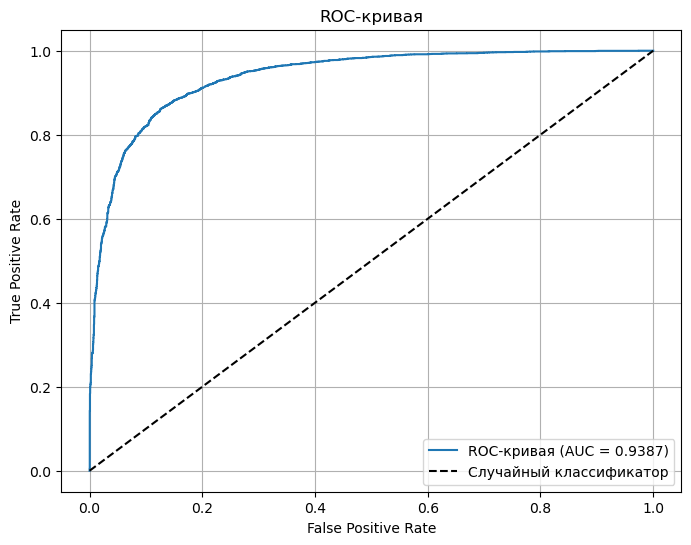

In [62]:
# Рассчитайте метрику AUC на тестовой выборке для lr_twit

# Получение вероятностей принадлежности к классам
y_pred_proba = lr_twit.predict_proba(X_twit_test)[:, 1]

# Расчет AUC
auc_score = roc_auc_score(y_twit_test, y_pred_proba)

print(f"AUC на тестовой выборке: {auc_score:.4f}")

# Для визуализации ROC-кривой (опционально)
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_twit_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

### **Извлечение признаков из временных рядов**

Целью извлечения признаков из временных рядов является преобразование исходного временного ряда (последовательности точек во времени) в набор информативных и компактных статических признаков. 

**Основные типы временных признаков:**

* Признаки на основе лагов (предыдущих значений ряда).

    * Лаговые признаки — это значения временного ряда из предыдущих моментов времени.

    * Скользящее среднее (moving average) — среднее значение за несколько предыдущих периодов.

* Признаки на основе даты и времени.

    * Временные компоненты: час, день недели, день месяца, месяц, год и т.д.

    * Бинарные флаги: является ли день выходным, праздничным и т.д.

* Циклические признаки. Чтобы сохранить информацию о цикличности, признаки преобразуют в двумерное пространство с помощью синуса и косинуса. Для признака со значением $x$ и периодом $T$ (например, для часа $T = 24$, для дня недели $T = 7$) создаются два новых признака:

    $$x_{\text{cos}} = \text{cos}(\frac{2 \pi x}{T})$$

    $$x_{\text{sin}} = \text{sin}(\frac{2 \pi x}{T})$$

*Это лишь основные и наиболее простые типы временных признаков. На практике их количество больше, а использование того или иного типа **зависит от решаемой задачи***.

### **Кросс-валидация временных рядов**

Классические методы кросс-валидации не могут быть использованы для временных рядов, упорядоченных во времени. Это связано с проблемой утечки данных (data leakage): случайное перемешивание временного ряда приведет к тому, что модель будет обучаться на данных из будущего, чтобы предсказать прошлое.

Для временных рядов необходимы особые стратегии кросс-валидации, которые сохраняют временной порядок данных.

**[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)** — это итератор кросс-валидации временных рядов из библиотеки scikit-learn. TimeSeriesSplit реализует подход, известный как кросс-валидация на расширяющемся окне (Expanding Window Cross-Validation): c каждой новой итерацией (фолдом) обучающая выборка увеличивается, а валидационная сдвигается вперед во времени.

TimeSeriesSplit может быть использован для подбора гиперпараметров с помощью GridSearchCV. Если **в качестве параметра cv** в GridSearchCV использовать разбиение временного ряда, полученное с помощью TimeSeriesSplit, GridSearchCV будет обучать и валидировать модель на соответствующих разбиениях (фолдах), обеспечивая корректную оценку качества модели.

### **Датасет *Hourly Energy Consumption***

**Для решения задания 5 рассмотрим датасет [Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption).**

Набор данных предназначен для анализа и прогнозирования почасового потребления электроэнергии в мегаваттах (MW) в различных регионах, входящих в PJM Interconnection LLC — региональную организацию по передаче электроэнергии в восточной части США. 

Целевая переменная — AEP_MW (количество потребляемой электроэнергии в мегаваттах за каждый час).

Единственная известная переменная датасета — Datetime (временная отметка с точностью до часа, которая указывает дату и время записи).

### ***Задание 5***

Используя значения ряда (AEP_MW), создайте признаки:

* Лаговые признаки (*подсказка: используйте [shift](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)*):

    * lag 1h — значение AEP_MW 1 час назад (временной лаг в 1 наблюдение). 

    * lag 24h — значение AEP_MW 24 часа назад (временной лаг в 24 наблюдения).

* Скользящее среднее (*подсказка: используйте признак **lag 1h** (скользящее среднее строится по **предыдущим** наблюдениям и не должно включать значение целевой переменной на момент прогноза) и [rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)*):

    * mean 24h — среднее AEP_MW за **предыдущие** 24 часа (скользящее среднее по 24 **предыдущим** наблюдениям).

    * mean 7d — среднее AEP_MW за **предыдущие** 7 дней (скользящее среднее по 24 $\times$ 7 **предыдущим** наблюдениям).

Используя метку времени (Datetime), создайте признаки:

* Временные компоненты:

    * hour: час.

    * weekday: день недели.

    * day: число месяца.

    * month: месяц.

    * year: год.

* Бинарные флаги:

    * is_weekend: метка выходного дня (суббота и воскресенье).

* Циклические признаки, закодированные с помощью косинуса и синуса:

    * hour_cos, hour_sin: cos и sin от hour ($T = 24$).

    * day_cos, day_sin: cos и sin от day ($T = 30$).

    * weekday_cos, weekday_sin: cos и sin от weekday ($T = 7$).

    * month_cos, month_sin: cos и sin от month ($T = 12$).

Разделите датасет на обучающую и тестовую выборки так, чтобы в обучающую выборку вошли все данные ранее 2017 года, в тестовую — все данные за 2017 год и позже.

Масштабируйте (стандартизируйте) все признаки на обучающей и тестовой выборке.

**На обучающей выборке** подберите оптимальные гиперпараметры обучения линейной регрессии с L2-регуляризацией (Ridge) с помощью **кросс-валидации временных рядов** (TimeSeriesSplit и GridSearchCV), метрика оптимизации — 'neg_mean_squared_error' (**отрицательный MSE**). Рассчитайте лучшее среднее значение **RMSE** (Root Mean Square Error, среднеквадратическая ошибка) по результатам кросс-валидации. 

Обучите модель Ridge `ridge_aep` с оптимальными гиперпараметрами на всей обучающей выборке и выведите metrics_report **на тестовой выборке**.

*Для данного задания предположим, что со временем среднее и дисперсия данных не изменились. Это позволит использовать один StandardScaler для обучающей и тестовой выборок.*

In [63]:
# Считайте набор данных

df_aep = pd.read_csv('AEP_hourly.csv')
df_aep

,Datetime,AEP_MW
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0
...,...,...
121264,2018-08-02 20:00:00,17673.0
121265,2018-08-02 21:00:00,17303.0
121266,2018-08-02 22:00:00,17001.0
121267,2018-08-02 23:00:00,15964.0


In [64]:
# Признак Datetime имеет тип данных object
# Необходимо изменить тип данных для Datetime

df_aep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121269 entries, 0 to 121268
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121269 non-null  object 
 1   AEP_MW    121269 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [65]:
# Измените тип Datetime на datetime64[ns]

df_aep['Datetime'] = pd.to_datetime(df_aep['Datetime'])

In [66]:
# Убедитесь, что тип данных Datetime — datetime64[ns]

df_aep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121269 entries, 0 to 121268
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121269 non-null  datetime64[ns]
 1   AEP_MW    121269 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB


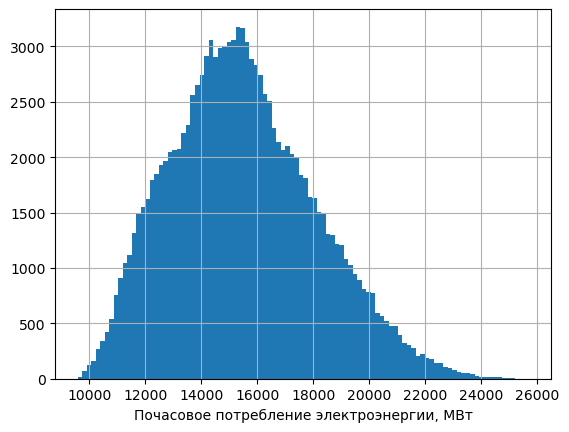

In [67]:
# Постройте гистограмму потребления электроэнергии

df_aep['AEP_MW'].hist(bins=100)
plt.xlabel('Почасовое потребление электроэнергии, МВт')
plt.show()

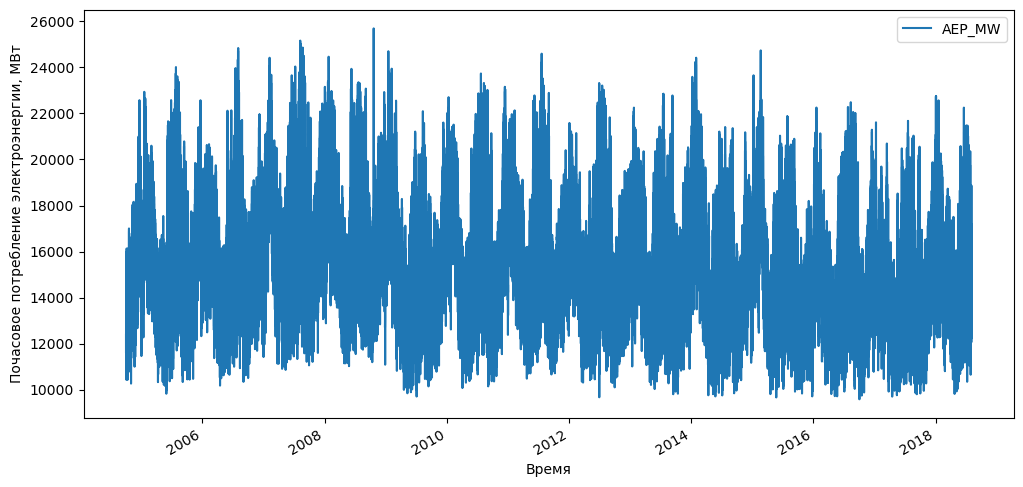

In [68]:
# Постройте график потребления электроэнергии

df_aep.plot(x='Datetime', y='AEP_MW', figsize=(12, 6))
plt.xlabel('Время')
plt.ylabel('Почасовое потребление электроэнергии, МВт')
plt.show()

In [69]:
# Создайте признаки lag 1h и lag 24h
# Подсказка: используйте shift

df_aep['lag 1h'] = df_aep['AEP_MW'].shift(1)
df_aep['lag 24h'] = df_aep['AEP_MW'].shift(24)

In [70]:
# Создайте признаки mean 24h и mean 7d
# Подсказка: используйте признак lag 1h и rolling

df_aep['mean 24h'] = df_aep['lag 1h'].rolling(window=24).mean()
df_aep['mean 7d'] = df_aep['lag 1h'].rolling(window=24*7).mean()

In [71]:
# Закодируйте метку времени (Datetime) как временные компоненты 

df_aep['hour'] = df_aep['Datetime'].dt.hour
df_aep['weekday'] = df_aep['Datetime'].dt.dayofweek  # Понедельник=0, воскресенье=6
df_aep['month'] = df_aep['Datetime'].dt.month
df_aep['day'] = df_aep['Datetime'].dt.day
df_aep['year'] = df_aep['Datetime'].dt.year

In [72]:
# Закодируйте метку времени (Datetime) как бинарный флаг is_weekend

df_aep['is_weekend'] = (df_aep['weekday'] >= 5).astype(int)

In [73]:
# Закодируйте циклические переменные с помощью косинуса и синуса

# Для часа (период T=24)
df_aep['hour_cos'] = np.cos(2 * np.pi * df_aep['hour'] / 24)
df_aep['hour_sin'] = np.sin(2 * np.pi * df_aep['hour'] / 24)

# Для дня (период T=30 - приблизительная длина месяца)
df_aep['day_cos'] = np.cos(2 * np.pi * df_aep['day'] / 30)
df_aep['day_sin'] = np.sin(2 * np.pi * df_aep['day'] / 30)

# Для дня недели (период T=7)
df_aep['weekday_cos'] = np.cos(2 * np.pi * df_aep['weekday'] / 7)
df_aep['weekday_sin'] = np.sin(2 * np.pi * df_aep['weekday'] / 7)

# Для месяца (период T=12)
df_aep['month_cos'] = np.cos(2 * np.pi * df_aep['month'] / 12)
df_aep['month_sin'] = np.sin(2 * np.pi * df_aep['month'] / 12)

**Пояснение:**
- Для каждого циклического признака создается два новых признака: косинус и синус
- Формула: $\cos(\frac{2 \pi x}{T})$ и $\sin(\frac{2 \pi x}{T})$, где $x$ - значение признака, $T$ - период
- Это преобразование сохраняет циклическую природу признаков (например, 23:00 и 00:00 - близкие значения, хотя численно они далеки)
- Для дня используется период T=30, так как это приблизительная длина месяца (максимальное значение дня может быть 31)

In [74]:
# Датасет после создания признаков

df_aep

,Datetime,AEP_MW,lag 1h,lag 24h,mean 24h,mean 7d,hour,weekday,month,day,year,is_weekend,hour_cos,hour_sin,day_cos,day_sin,weekday_cos,weekday_sin,month_cos,month_sin
0,2004-10-01 01:00:00,12379.0,NaN,NaN,NaN,NaN,1,4,10,1,2004,0,0.965926,0.258819,0.978148,0.207912,-0.900969,-0.433884,0.5,-0.866025
1,2004-10-01 02:00:00,11935.0,12379.0,NaN,NaN,NaN,2,4,10,1,2004,0,0.866025,0.500000,0.978148,0.207912,-0.900969,-0.433884,0.5,-0.866025
2,2004-10-01 03:00:00,11692.0,11935.0,NaN,NaN,NaN,3,4,10,1,2004,0,0.707107,0.707107,0.978148,0.207912,-0.900969,-0.433884,0.5,-0.866025
3,2004-10-01 04:00:00,11597.0,11692.0,NaN,NaN,NaN,4,4,10,1,2004,0,0.500000,0.866025,0.978148,0.207912,-0.900969,-0.433884,0.5,-0.866025
4,2004-10-01 05:00:00,11681.0,11597.0,NaN,NaN,NaN,5,4,10,1,2004,0,0.258819,0.965926,0.978148,0.207912,-0.900969,-0.433884,0.5,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121264,2018-08-02 20:00:00,17673.0,18118.0,16579.0,15543.958333,15018.565476,20,3,8,2,2018,0,0.500000,-0.866025,0.913545,0.406737,-0.900969,0.433884,-0.5,-0.866025
121265,2018-08-02 21:00:00,17303.0,17673.0,16457.0,15589.541667,15010.630952,21,3,8,2,2018,0,0.707107,-0.707107,0.913545,0.406737,-0.900969,0.433884,-0.5,-0.866025
121266,2018-08-02 22:00:00,17001.0,17303.0,16197.0,15624.791667,15004.565476,22,3,8,2,2018,0,0.866025,-0.500000,0.913545,0.406737,-0.900969,0.433884,-0.5,-0.866025
121267,2018-08-02 23:00:00,15964.0,17001.0,15259.0,15658.291667,14999.785714,23,3,8,2,2018,0,0.965926,-0.258819,0.913545,0.406737,-0.900969,0.433884,-0.5,-0.866025


In [75]:
# Удалите строки с пропущенными значениями
# Пропущенные значения появились после создания лаговых признаков и скользящих средних

df_aep = df_aep.dropna()

In [76]:
# Выделите объясняемый фактор в отдельную переменную
# Также удалите метку времени (Datetime) из объясняющих переменных

# Удаляем целевую переменную (AEP_MW) и метку времени (Datetime) из признаков
X_aep = df_aep.drop(['AEP_MW', 'Datetime'], axis=1)

# Целевая переменная
y_aep = df_aep['AEP_MW']

In [77]:
# Разделите датасет на обучающую и тестовую выборки:
#   Обучающая выборка — все данные ранее 2017 года
#   Тестовая выборка  — все данные за 2017 год и позже

# Обучающая выборка (данные ранее 2017 года)
X_aep_train = X_aep[df_aep['year'] < 2017]
y_aep_train = y_aep[df_aep['year'] < 2017]

# Тестовая выборка (данные за 2017 год и позже)
X_aep_test = X_aep[df_aep['year'] >= 2017]
y_aep_test = y_aep[df_aep['year'] >= 2017]

In [78]:
# Масштабируйте все признаки
#   train -> fit_transform
#   test -> transform

aep_scaler = StandardScaler().set_output(transform='pandas')

X_aep_train_scaled = aep_scaler.fit_transform(X_aep_train)
X_aep_test_scaled = aep_scaler.transform(X_aep_test)

In [79]:
# На обучающей выборке подберите оптимальные гиперпараметры обучения Ridge с помощью кросс-валидации временных рядов
# Используйте TimeSeriesSplit и GridSearchCV
# Не забудьте зафиксировать RANDOM_STATE

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

params = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
}
scoring = 'neg_mean_squared_error'
cv = 10

tscv = TimeSeriesSplit(n_splits=cv)

cv_ridge_aep = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=params,
    scoring=scoring,
    cv=tscv,
    n_jobs=-1
).fit(X_aep_train_scaled, y_aep_train)

In [80]:
# Рассчитайте лучшее среднее значение RMSE по результатам кросс-валидации

best_rmse_cv = np.sqrt(-cv_ridge_aep.best_score_)
print(f"Лучшее значение RMSE на кросс-валидации: {best_rmse_cv:.4f}")
print(f"Лучший параметр alpha: {cv_ridge_aep.best_params_['alpha']}")

Лучшее значение RMSE на кросс-валидации: 429.8649
Лучший параметр alpha: 0.001


In [81]:
# Обучите ridge_aep с оптимальными гиперпараметрами на всей обучающей выборке и выведите metrics_report на тестовой выборке

# Обучение модели с оптимальными гиперпараметрами на всей обучающей выборке
ridge_aep = Ridge(alpha=cv_ridge_aep.best_params_['alpha'], random_state=RANDOM_STATE)
ridge_aep.fit(X_aep_train_scaled, y_aep_train)

# Предсказание на тестовой выборке
y_pred = ridge_aep.predict(X_aep_test_scaled)

# Вывод отчета с метриками
metrics_report(y_aep_test, y_pred)

R2 score: 0.9730
RMSE: 394.9421
MAPE: 0.0206


### **Отбор признаков**

**Отбор признаков** (feature selection) — это процесс выбора наиболее информативных переменных из исходного набора данных. Такой подход позволяет упростить модель, сократить время обучения, повысить точность и уменьшить переобучение. Существует три основные группы методов: фильтры, обёртки и встроенные методы.

**Фильтры (filter methods)** 

Фильтры оценивают важность признаков на основе статистических критериев независимо от используемой модели машинного обучения. Признаки оцениваются по отдельности, а затем выбирается подмножество признаков, которые лучше всего коррелируют с целевой переменной.

Такие методы просты в реализации и быстры, но не учитывают взаимодействие между признаками и специфику модели. 

Примеры методов: 

* Корреляционный анализ.

* Критерий $\chi^2$ (хи-квадрат).

* ANOVA F-тест.

**Обёртки (wrapper methods)**

Обёртки используют модели для оценки качества различных подмножеств признаков. Эти методы перебирают различные комбинации признаков, обучают модель и сравнивают качество прогнозов.

Такие методы способны учитывать взаимодействие признаков и специфику модели, но вычислительно затратны.

Примеры методов:

* SFS (Sequential Forward Selection). Отбор начинается с пустого множества признаков. На каждом шаге к текущему набору добавляется тот признак, который при включении даёт наибольшее улучшение качества модели. Процесс продолжается до тех пор, когда не будет достигнут заданный размер подмножества или когда дальнейшее добавление признаков не будет улучшать качество.

* SBS (Sequential Backward Selection). Отбор начинается со всех признаков. На каждом шаге удаляется тот признак, чьё исключение меньше всего ухудшает качество модели. Процесс повторяется, пока не останется заданное число признаков.

* RFE (Recursive Feature Elimination). Отбор осуществляется на основе коэффициентов или важности признаков в обученной модели путем удаления наименее значимого признака. Процесс повторяется рекурсивно, пока не останется заданное количество признаков.

**Встроенные методы (embedded methods)**

Встроенные методы производят отбор признаков непосредственно в процессе обучения модели: используются внутренние механизмы модели для определения важности признаков. 

Встроенные методы сочетают преимущества фильтрующих (скорость) и оберточных (учет специфики модели) методов. 

Примеры методов: 

* L1-регуляризация (LASSO) для линейных моделей.

* Feature Importance в деревьях решений и ансамблевых методах (Random Forest, Gradient Boosting).

*На практике перечисленные методы могут комбинироваться. Например, сначала с помощью фильтра убираются малоинформативные признаки, а затем применяется обёртка для более точного отбора признаков.*

Подробнее можно изучить по **ссылкам:**

* [Comprehensive Guide on Feature Selection | kaggle.com](https://www.kaggle.com/code/prashant111/comprehensive-guide-on-feature-selection)

* [Отбор признаков (Feature selection) | scikit-learn.ru](https://scikit-learn.ru/stable/modules/feature_selection.html#univariate-feature-selection)

### **Датасет *Company Bankruptcy Prediction***

**Для решения задания 6 рассмотрим датасет [Company Bankruptcy Prediction](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction).**

**ВНИМАНИЕ:** При решении задания **используйте файл bankruptcy.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Набор данных предназначен для выявления компаний с высоким риском банкротства на основе их финансовых показателей. Данные были собраны из базы данных компании Taiwan Economic Journal за период с 1999 по 2009 годы.

Целевая переменная — Bankrupt? (банкротство компании):

0 — в течение рассматриваемого периода компания работала без признаков банкротства.

1 — компания обанкротилась в течение рассматриваемого периода.

В датасете содержатся 94 различных показателей финансового состояния компаний, значения которых были предварительно стандартизированы.

Одной из особенностей набора данных является дисбаланс классов в целевой переменной: только 3.22% от числа компаний в выборке были признаны банкротами за указанный период. 

### ***Задание 6***

Используя все признаки, обучите baseline модель логистической регрессии (LogisticRegression) `lr_bankr_baseline` с параметрами:

* solver='liblinear' — алгоритм оптимизации, который поддерживает L1 и L2 регуляризации.

* class_weight='balanced' — корректировка веса классов обратно пропорционально их частотам в обучающем наборе данных.

* random_state=RANDOM_STATE.

*Baseline — это базовая модель, которая используется как отправная точка для оценки и сравнения более продвинутых моделей в задачах машинного обучения.*

Выполните отбор признаков тремя методами и обучите модели на оптимальном наборе признаков:

* **Фильтр: ANOVA F-тест (SelectKBest).**

    1. Постройте пайплайн `bankr_kbest_pipeline`:

        1. 'selector': [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html)([f_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html)) — выбирает k лучших признаков на основе оценки ANOVA F-теста.

        2. 'clf': LogisticRegression с теми же параметрами, что и baseline модель.

    2. С помощью GridSearchCV и пайплайна `bankr_kbest_pipeline` подберите на обучающей выборке оптимальное количество признаков $k_{\text{KBest}}$, где $k_{\text{KBest}}$ — число от 1 до 40.

    3. На оптимальном наборе из $k_{\text{KBest}}$ признаков на всей обучающей выборке обучите модель (пайплайн) `lr_bankr_kbest` с теми же параметрами, что и baseline модель.

* **Обёртка: SFS (SequentialFeatureSelector).**

    1. Используя [SequentialFeatureSelector](https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.feature_selection/#sequentialfeatureselector) из библиотеки mlxtend, подберите на обучающей выборке оптимальный набор из $k_{\text{SFS}}$ признаков, где $k_{\text{SFS}}$ — число от 1 до 40.

    2. На оптимальном наборе из $k_{\text{SFS}}$ признаков на всей обучающей выборке обучите модель `lr_bankr_sfs` с теми же параметрами, что и baseline модель.

* **Встроенный метод: L1 регуляризация.**

    1. С помощью GridSearchCV подберите на обучающей выборке значение оптимального гиперпараметра регуляризации C для **логистической регрессии с L1 регуляризацией** (остальные параметры те же, что и в baseline модели).

    2. На всей обучающей выборке обучите модель с L1 регуляризацией `lr_bankr_l1`, в качестве параметров используя оптимальный гиперпараметр регуляризации и те же параметры, что и в baseline модели.

Для обученных моделей `lr_bankr_kbest`, `lr_bankr_sfs` и `lr_bankr_l1` определите количество отобранных признаков k.

На тестовой выборке для всех моделей, включая baseline (`lr_bankr`, `lr_bankr_kbest`, `lr_bankr_sfs` и `lr_bankr_l1`), постройте  отчёты по метрикам классификации, рассчитайте метрики f1 и AUC.

In [82]:
# Считайте данные

df_bankr = pd.read_csv('bankruptcy.csv')
df_bankr

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [83]:
# Всего в датасете 94 признаков (без учета целевой переменной)
# Пропущенные значения отсутствуют 

df_bankr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

In [84]:
# В датасете присутствует дисбаланс классов

df_bankr['Bankrupt?'].value_counts(normalize=True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

In [85]:
# Выделите объясняемый фактор в отдельную переменную

X_bankr, y_bankr = df_bankr.drop('Bankrupt?', axis=1), df_bankr['Bankrupt?']

In [86]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_bankr_train, X_bankr_test, y_bankr_train, y_bankr_test = train_test_split(
    X_bankr, 
    y_bankr, 
    test_size=0.4, 
    random_state=RANDOM_STATE, 
    stratify=y_bankr
)

In [87]:
# Обучите baseline модель lr_bankr_baseline
# Не забудьте зафиксировать RANDOM_STATE

# Создание и обучение модели
lr_bankr_baseline = LogisticRegression(
    random_state=RANDOM_STATE, 
    solver='liblinear', 
    class_weight='balanced'
)

# Обучение на тренировочных данных
lr_bankr_baseline.fit(X_bankr_train, y_bankr_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

In [88]:
# Постройте отчет по метрикам классификации для модели lr_bankr на тестовой выборке

# Получаем предсказания и вероятности для тестовой выборки
y_pred_baseline = lr_bankr_baseline.predict(X_bankr_test)
y_pred_proba_baseline = lr_bankr_baseline.predict_proba(X_bankr_test)[:, 1]

# Выводим отчет по метрикам
print("=" * 60)
print("BASELINE MODEL (lr_bankr_baseline) PERFORMANCE ON TEST SET")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_bankr_test, y_pred_baseline, target_names=['No Bankruptcy (0)', 'Bankruptcy (1)']))

print(f"\nF1 Score: {f1_score(y_bankr_test, y_pred_baseline):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_bankr_test, y_pred_proba_baseline):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_bankr_test, y_pred_baseline))

BASELINE MODEL (lr_bankr_baseline) PERFORMANCE ON TEST SET

Classification Report:
                   precision    recall  f1-score   support

No Bankruptcy (0)       0.97      0.80      0.88      2640
   Bankruptcy (1)       0.05      0.35      0.09        88

         accuracy                           0.78      2728
        macro avg       0.51      0.57      0.49      2728
     weighted avg       0.94      0.78      0.85      2728


F1 Score: 0.0949
AUC-ROC: 0.6397

Confusion Matrix:
[[2106  534]
 [  57   31]]


In [89]:
# Посчитайте f1 для модели lr_bankr_baseline на тестовой выборке

f1_baseline = f1_score(y_bankr_test, y_pred_baseline)
print(f"F1 Score for baseline model: {f1_baseline:.4f}")

F1 Score for baseline model: 0.0949


In [90]:
# Посчитайте AUC для модели lr_bankr_baseline на тестовой выборке

# Получаем вероятности предсказаний для тестовой выборки (нужны для AUC)
y_pred_proba_baseline = lr_bankr_baseline.predict_proba(X_bankr_test)[:, 1]

# Рассчитываем AUC
auc_baseline = roc_auc_score(y_bankr_test, y_pred_proba_baseline)

print(f"AUC Score for baseline model: {auc_baseline:.4f}")

AUC Score for baseline model: 0.6397


In [91]:
# Постройте пайплайн bankr_kbest_pipeline (см. задание)
# Не забудьте зафиксировать RANDOM_STATE

bankr_kbest_pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(
        random_state=RANDOM_STATE, 
        solver='liblinear', 
        class_weight='balanced'
    ))
])

In [92]:
# С помощью GridSearchCV и bankr_kbest_pipeline подберите на обучающей выборке оптимальное количество признаков

from sklearn.model_selection import GridSearchCV

params = {
    'selector__k': range(1, 40)  # параметр k для SelectKBest
}
scoring = 'f1'
cv = 5

cv_lr_bankr_kbest = GridSearchCV(
    estimator=bankr_kbest_pipeline, 
    param_grid=params,
    scoring=scoring,
    cv=cv, 
    n_jobs=-1
).fit(X_bankr_train, y_bankr_train)

# Выведем результаты
print(f"Лучшее значение F1 на кросс-валидации: {cv_lr_bankr_kbest.best_score_:.4f}")

Лучшее значение F1 на кросс-валидации: 0.2766


In [93]:
# Выведите оптимальное количество признаков для bankr_kbest_pipeline

print(f"Оптимальное количество признаков (k): {cv_lr_bankr_kbest.best_params_['selector__k']}")

Оптимальное количество признаков (k): 7


In [94]:
# На наборе из оптимального числа признаков на всей обучающей выборке обучите модель lr_bankr_kbest

# Используем лучшую модель из GridSearchCV (она уже обучена на всей обучающей выборке)
lr_bankr_kbest = cv_lr_bankr_kbest.best_estimator_

# Получаем количество отобранных признаков
# Для SelectKBest нужно получить маску или индексы выбранных признаков
selector = lr_bankr_kbest.named_steps['selector']
k_features = selector.k
print(f"Модель lr_bankr_kbest использует {k_features} признаков")

# На наборе из оптимального числа признаков на всей обучающей выборке обучите модель lr_bankr_kbest

# Получаем оптимальное количество признаков
optimal_k = cv_lr_bankr_kbest.best_params_['selector__k']

# Создаем и обучаем модель с оптимальным k
lr_bankr_kbest = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=optimal_k)),
    ('clf', LogisticRegression(
        random_state=RANDOM_STATE, 
        solver='liblinear', 
        class_weight='balanced'
    ))
])

lr_bankr_kbest.fit(X_bankr_train, y_bankr_train)

# Сохраняем количество признаков для последующего использования в задании
k_kbest = optimal_k
print(f"Количество отобранных признаков (kBest): {k_kbest}")

Модель lr_bankr_kbest использует 7 признаков
Количество отобранных признаков (kBest): 7


In [95]:
# Постройте отчет по метрикам классификации для модели lr_bankr_kbest на тестовой выборке

# Получаем предсказания и вероятности для тестовой выборки
y_pred_kbest = lr_bankr_kbest.predict(X_bankr_test)

# Выводим отчет по метрикам
print("=" * 60)
print("MODEL WITH KBEST FEATURE SELECTION (lr_bankr_kbest) PERFORMANCE ON TEST SET")
print("=" * 60)
print(f"\nКоличество отобранных признаков: {lr_bankr_kbest.named_steps['selector'].k}")
print("\nClassification Report:")
print(classification_report(y_bankr_test, y_pred_kbest, target_names=['No Bankruptcy (0)', 'Bankruptcy (1)']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_bankr_test, y_pred_kbest))

MODEL WITH KBEST FEATURE SELECTION (lr_bankr_kbest) PERFORMANCE ON TEST SET

Количество отобранных признаков: 7

Classification Report:
                   precision    recall  f1-score   support

No Bankruptcy (0)       0.99      0.85      0.91      2640
   Bankruptcy (1)       0.16      0.86      0.27        88

         accuracy                           0.85      2728
        macro avg       0.58      0.85      0.59      2728
     weighted avg       0.97      0.85      0.89      2728


Confusion Matrix:
[[2231  409]
 [  12   76]]


In [96]:
# Посчитайте f1 для модели lr_bankr_kbest на тестовой выборке

f1_kbest = f1_score(y_bankr_test, y_pred_kbest)
print(f"F1 Score: {f1_kbest:.4f}")

F1 Score: 0.2653


In [97]:
# Посчитайте AUC для модели lr_bankr_kbest на тестовой выборке

# Получаем вероятности предсказаний для тестовой выборки
y_pred_proba_kbest = lr_bankr_kbest.predict_proba(X_bankr_test)[:, 1]

# Рассчитываем AUC
auc_kbest = roc_auc_score(y_bankr_test, y_pred_proba_kbest)

print(f"AUC Score for lr_bankr_kbest model: {auc_kbest:.4f}")

AUC Score for lr_bankr_kbest model: 0.9280


In [98]:
# Используя SequentialFeatureSelector, подберите на обучающей выборке оптимальный набор признаков
# Не забудьте зафиксировать RANDOM_STATE

from mlxtend.feature_selection import SequentialFeatureSelector

# Создаем модель логистической регрессии с теми же параметрами
lr_for_sfs = LogisticRegression(
    random_state=RANDOM_STATE, 
    solver='liblinear', 
    class_weight='balanced'
)

bankr_sfs = SequentialFeatureSelector(
    estimator=lr_for_sfs, 
    k_features=(1, 40),  # от 1 до 40 признаков
    forward=True, 
    floating=False,
    scoring='f1',
    cv=5,
    n_jobs=-1
).fit(X_bankr_train, y_bankr_train)

# Выведем результаты
print(f"Лучшее значение F1 на кросс-валидации: {bankr_sfs.k_score_:.4f}")

Лучшее значение F1 на кросс-валидации: 0.4205


In [99]:
# Выведите оптимальное количество признаков после SFS

print(f"Оптимальное количество признаков (SFS): {len(bankr_sfs.k_feature_idx_)}")
print(f"Индексы отобранных признаков: {bankr_sfs.k_feature_idx_}")

Оптимальное количество признаков (SFS): 9
Индексы отобранных признаков: (7, 27, 30, 40, 64, 68, 72, 89, 91)


In [100]:
# Создайте новые выборки с оптимальными признаками после SFS

# Получаем названия отобранных признаков
selected_features = X_bankr_train.columns[list(bankr_sfs.k_feature_idx_)]

# Создаем новые выборки только с отобранными признаками
X_bankr_train_sfs = X_bankr_train[selected_features]
X_bankr_test_sfs = X_bankr_test[selected_features]

# Проверяем результат
print(f"Размерность обучающей выборки после SFS: {X_bankr_train_sfs.shape}")
print(f"Размерность тестовой выборки после SFS: {X_bankr_test_sfs.shape}")
print(f"Количество отобранных признаков (k_SFS): {len(selected_features)}")

# Сохраняем количество признаков для последующего использования
k_sfs = len(selected_features)
print(f"Оптимальное количество признаков k_SFS = {k_sfs}")

Размерность обучающей выборки после SFS: (4091, 9)
Размерность тестовой выборки после SFS: (2728, 9)
Количество отобранных признаков (k_SFS): 9
Оптимальное количество признаков k_SFS = 9


In [101]:
# На оптимальном наборе признаков на всей обучающей выборке обучите модель lr_bankr_sfs
# Не забудьте зафиксировать RANDOM_STATE

lr_bankr_sfs = LogisticRegression(
    random_state=RANDOM_STATE,
    solver='liblinear',
    class_weight='balanced'
).fit(X_bankr_train_sfs, y_bankr_train)

k_sfs = X_bankr_train_sfs.shape[1]
print(f"Модель lr_bankr_sfs обучена с количеством признаков k_SFS = {k_sfs}")

Модель lr_bankr_sfs обучена с количеством признаков k_SFS = 9


In [102]:
# Постройте отчет по метрикам классификации для модели lr_bankr_sfs на тестовой выборке

from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

# Получаем предсказания и вероятности для тестовой выборки
y_pred_sfs = lr_bankr_sfs.predict(X_bankr_test_sfs)
y_pred_proba_sfs = lr_bankr_sfs.predict_proba(X_bankr_test_sfs)[:, 1]

# Выводим отчет по метрикам
print("=" * 60)
print("MODEL WITH SFS FEATURE SELECTION (lr_bankr_sfs) PERFORMANCE ON TEST SET")
print("=" * 60)
print(f"\nКоличество отобранных признаков: {X_bankr_train_sfs.shape[1]}")
print("\nClassification Report:")
print(classification_report(y_bankr_test, y_pred_sfs, target_names=['No Bankruptcy (0)', 'Bankruptcy (1)']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_bankr_test, y_pred_sfs))

MODEL WITH SFS FEATURE SELECTION (lr_bankr_sfs) PERFORMANCE ON TEST SET

Количество отобранных признаков: 9

Classification Report:
                   precision    recall  f1-score   support

No Bankruptcy (0)       0.98      0.97      0.98      2640
   Bankruptcy (1)       0.35      0.42      0.38        88

         accuracy                           0.96      2728
        macro avg       0.66      0.70      0.68      2728
     weighted avg       0.96      0.96      0.96      2728


Confusion Matrix:
[[2570   70]
 [  51   37]]


In [103]:
# Посчитайте f1 для модели lr_bankr_sfs на тестовой выборке

f1_sfs = f1_score(y_bankr_test, lr_bankr_sfs.predict(X_bankr_test_sfs))
print(f"F1 Score for SFS model: {f1_sfs:.4f}")

F1 Score for SFS model: 0.3795


In [104]:
# Посчитайте AUC для модели lr_bankr_sfs на тестовой выборке

auc_sfs = roc_auc_score(y_bankr_test, lr_bankr_sfs.predict_proba(X_bankr_test_sfs)[:, 1])
print(f"AUC Score for SFS model: {auc_sfs:.4f}")

AUC Score for SFS model: 0.8217


In [105]:
# С помощью GridSearchCV подберите на обучающей выборке значение оптимального гиперпараметра регуляризации C
# Не забудьте зафиксировать RANDOM_STATE

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Создаем модель логистической регрессии с L1 регуляризацией
estimator = LogisticRegression(
    random_state=RANDOM_STATE,
    solver='liblinear',  # liblinear поддерживает L1 регуляризацию
    penalty='l1',
    class_weight='balanced'
)

# Параметры для перебора
params = {'C': [0.001, 0.01, 0.1, 1.0, 10.0]}  # Расширенный список значений C
cv = 5
scoring = 'f1'

# GridSearchCV для подбора оптимального C
cv_lr_bankr_l1 = GridSearchCV(
    estimator=estimator,
    param_grid=params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
).fit(X_bankr_train, y_bankr_train)

# Выводим результаты
print(f"Оптимальное значение C: {cv_lr_bankr_l1.best_params_['C']}")
print(f"Лучшее значение F1 на кросс-валидации: {cv_lr_bankr_l1.best_score_:.4f}")

Оптимальное значение C: 10.0
Лучшее значение F1 на кросс-валидации: 0.2788


In [106]:
# На всей обучающей выборке обучите модель с L1 регуляризацией lr_bankr_l1
# Не забудьте зафиксировать RANDOM_STATE

# Получаем оптимальное значение C из GridSearchCV
optimal_C = cv_lr_bankr_l1.best_params_['C']

# Создаем и обучаем модель с L1 регуляризацией и оптимальным C
lr_bankr_l1 = LogisticRegression(
    random_state=RANDOM_STATE,
    solver='liblinear',  # liblinear поддерживает L1 регуляризацию
    penalty='l1',
    C=optimal_C,
    class_weight='balanced'
).fit(X_bankr_train, y_bankr_train)

print(f"Модель lr_bankr_l1 обучена с параметрами:")
print(f"  - penalty='l1'")
print(f"  - C = {optimal_C:.4f}")
print(f"  - solver='liblinear'")
print(f"  - class_weight='balanced'")
print(f"  - random_state={RANDOM_STATE}")

Модель lr_bankr_l1 обучена с параметрами:
  - penalty='l1'
  - C = 10.0000
  - solver='liblinear'
  - class_weight='balanced'
  - random_state=42


In [107]:
# Выведите количество отобранных признаков (признаков, регрессионный коэффициент при которых не равен 0) в lr_bankr_l1

# Получаем коэффициенты модели
coefficients = lr_bankr_l1.coef_[0]

# Считаем количество ненулевых коэффициентов
k_l1 = np.sum(coefficients != 0)

print("=" * 60)
print("L1 РЕГУЛЯРИЗАЦИЯ - ОТОБРАННЫЕ ПРИЗНАКИ")
print("=" * 60)
print(f"Количество отобранных признаков (ненулевые коэффициенты): {k_l1}")
print(f"Общее количество признаков: {len(coefficients)}")
print(f"Доля отобранных признаков: {k_l1/len(coefficients)*100:.1f}%")
print(f"Количество обнуленных признаков: {len(coefficients) - k_l1}")

# Покажем распределение коэффициентов
print(f"\nСтатистика коэффициентов:")
print(f"  Минимальный коэффициент: {np.min(coefficients):.4f}")
print(f"  Максимальный коэффициент: {np.max(coefficients):.4f}")
print(f"  Средний коэффициент (ненулевые): {np.mean(coefficients[coefficients != 0]):.4f}")

# Создаем DataFrame с признаками и их коэффициентами для наглядности
feature_importance = pd.DataFrame({
    'feature': X_bankr_train.columns,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Сортируем по абсолютному значению коэффициента
feature_importance = feature_importance[feature_importance['coefficient'] != 0].sort_values('abs_coefficient', ascending=False)

print(f"\nТоп-10 наиболее важных признаков (по абсолютному значению коэффициента):")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['coefficient']:.4f}")

L1 РЕГУЛЯРИЗАЦИЯ - ОТОБРАННЫЕ ПРИЗНАКИ
Количество отобранных признаков (ненулевые коэффициенты): 93
Общее количество признаков: 95
Доля отобранных признаков: 97.9%
Количество обнуленных признаков: 2

Статистика коэффициентов:
  Минимальный коэффициент: -19.4904
  Максимальный коэффициент: 31.0118
  Средний коэффициент (ненулевые): 0.1133

Топ-10 наиболее важных признаков (по абсолютному значению коэффициента):
  Realized Sales Gross Profit Growth Rate: 31.0118
  Debt ratio %: 23.4432
  Net Worth Turnover Rate (times): -19.4904
  Net profit before tax/Paid-in capital: -12.1323
  Persistent EPS in the Last Four Seasons: -10.6759
  Per Share Net profit before tax (Yuan ¥): -10.3819
  Revenue per person: 9.0627
  Equity to Long-term Liability: 7.4353
  Total expense/Assets: 6.1516
  Cash/Total Assets: -5.4896


In [108]:
# Постройте отчет по метрикам классификации для модели lr_bankr_l1 на тестовой выборке

from sklearn.metrics import classification_report

y_pred_l1 = lr_bankr_l1.predict(X_bankr_test)
print("Classification Report for lr_bankr_l1:")
print(classification_report(y_bankr_test, y_pred_l1))

Classification Report for lr_bankr_l1:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2640
           1       0.17      0.82      0.29        88

    accuracy                           0.87      2728
   macro avg       0.58      0.84      0.61      2728
weighted avg       0.97      0.87      0.91      2728



In [109]:
# Посчитайте f1 для модели lr_bankr_l1 на тестовой выборке

f1_l1 = f1_score(y_bankr_test, lr_bankr_l1.predict(X_bankr_test))
print(f"F1 Score for L1 model: {f1_l1:.4f}")

F1 Score for L1 model: 0.2857


In [110]:
# Посчитайте AUC для модели lr_bankr_l1 на тестовой выборке

auc_l1 = roc_auc_score(y_bankr_test, lr_bankr_l1.predict_proba(X_bankr_test)[:, 1])
print(f"AUC Score for L1 model: {auc_l1:.4f}")

AUC Score for L1 model: 0.9212


In [111]:
# Сравнительная таблица для всех моделей по F1, AUC и количеству признаков

import pandas as pd

# Создаем DataFrame
df_comparison = pd.DataFrame({
    'Модель': ['Baseline', 'KBest', 'SFS', 'L1'],
    'F1 Score': [f1_baseline, f1_kbest, f1_sfs, f1_l1],
    'AUC': [auc_baseline, auc_kbest, auc_sfs, auc_l1],
    'Признаки': [X_bankr_train.shape[1], k_kbest, k_sfs, k_l1]
})

# Добавляем процент признаков
df_comparison['% признаков'] = (df_comparison['Признаки'] / X_bankr_train.shape[1] * 100).round(1)

# Округляем метрики
df_comparison['F1 Score'] = df_comparison['F1 Score'].round(4)
df_comparison['AUC'] = df_comparison['AUC'].round(4)

# Устанавливаем модель как индекс для лучшего отображения
df_comparison.set_index('Модель', inplace=True)

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")
print("=" * 60)
print(df_comparison.to_string())
print("=" * 60)

# Добавляем строку с лучшими значениями
print(f"\nЛучшая модель по F1: {df_comparison['F1 Score'].idxmax()} ({df_comparison['F1 Score'].max():.4f})")
print(f"Лучшая модель по AUC: {df_comparison['AUC'].idxmax()} ({df_comparison['AUC'].max():.4f})")
print(f"Наименьшее количество признаков: {df_comparison['Признаки'].idxmin()} ({df_comparison['Признаки'].min()} признаков)")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
          F1 Score     AUC  Признаки  % признаков
Модель                                           
Baseline    0.0949  0.6397        95        100.0
KBest       0.2653  0.9280         7          7.4
SFS         0.3795  0.8217         9          9.5
L1          0.2857  0.9212        93         97.9

Лучшая модель по F1: SFS (0.3795)
Лучшая модель по AUC: KBest (0.9280)
Наименьшее количество признаков: KBest (7 признаков)
